<a href="https://colab.research.google.com/github/nattntn/DPDM2024/blob/main/Research_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#เชื่อม google drive
from google.colab  import drive
drive.mount('/content/gdrive')

# Data preprocessing  
  
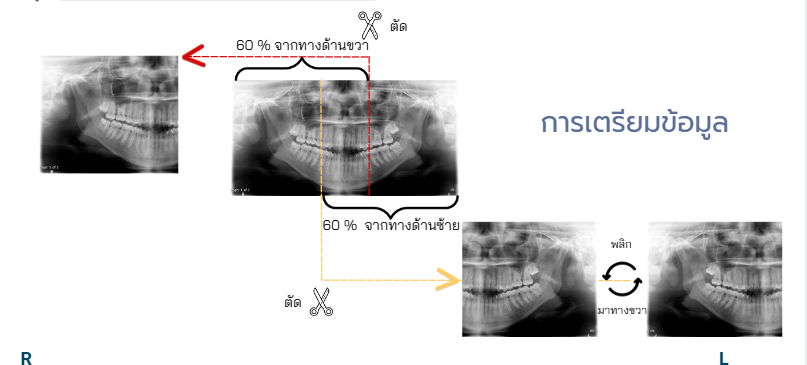


In [ ]:
import pandas as pd
import shutil
import cv2
import PIL
from PIL import Image
import os
import glob
import numpy as np
import sys

In [ ]:
df =  pd.read_csv (r'/content/gdrive/MyDrive/Tooth_Shap_GPT/Deep_tooth/dataset ที่แยก nor|abnor|nor&abnor/dataที่มีแค่normal.csv')
df

## Y7

In [ ]:
base_dir = '/content/gdrive/MyDrive/Tooth_Shap_GPT/Deep_tooth/Data_Cut_images'
os.makedirs(base_dir, exist_ok=True)

# Directories for our training,
# validation and test splits
Full_image_dir = os.path.join(base_dir, 'Normal')
os.makedirs(Full_image_dir, exist_ok=True)

In [ ]:
Full_image_Y7 = os.path.join(Full_image_dir, '7Y')
os.makedirs(Full_image_Y7, exist_ok=True)

In [ ]:
Full_image_Y7_F = os.path.join(Full_image_Y7, 'F')
os.makedirs(Full_image_Y7_F, exist_ok=True)

Full_image_Y7_M = os.path.join(Full_image_Y7, 'M')
os.makedirs(Full_image_Y7_M, exist_ok=True)

In [ ]:
Full_image_Y7_F_Both = os.path.join(Full_image_Y7_F, 'Both')
os.makedirs(Full_image_Y7_F_Both, exist_ok=True)

Full_image_Y7_F_Lt = os.path.join(Full_image_Y7_F, 'Lt')
os.makedirs(Full_image_Y7_F_Lt, exist_ok=True)

Full_image_Y7_F_Rt = os.path.join(Full_image_Y7_F, 'Rt')
os.makedirs(Full_image_Y7_F_Rt , exist_ok=True)
#######################################
Full_image_Y7_M_Both = os.path.join(Full_image_Y7_M, 'Both')
os.makedirs(Full_image_Y7_M_Both, exist_ok=True)

Full_image_Y7_M_Lt = os.path.join(Full_image_Y7_M, 'Lt')
os.makedirs(Full_image_Y7_M_Lt, exist_ok=True)

Full_image_Y7_M_Rt = os.path.join(Full_image_Y7_M, 'Rt')
os.makedirs(Full_image_Y7_M_Rt , exist_ok=True)

In [ ]:
Full_image_Y7_F_Both_Unflip = os.path.join(Full_image_Y7_F_Both , 'Unflip')
os.makedirs(Full_image_Y7_F_Both_Unflip, exist_ok=True)

Full_image_Y7_F_Lt_Unflip = os.path.join(Full_image_Y7_F_Lt, 'Unflip')
os.makedirs(Full_image_Y7_F_Lt_Unflip, exist_ok=True)
#######################################
Full_image_Y7_M_Both_Unflip = os.path.join(Full_image_Y7_M_Both, 'Unflip')
os.makedirs(Full_image_Y7_M_Both_Unflip, exist_ok=True)

Full_image_Y7_M_Lt_Unflip = os.path.join(Full_image_Y7_M_Lt, 'Unflip')
os.makedirs(Full_image_Y7_M_Lt_Unflip, exist_ok=True)



### F

#### Y7-F_Both

In [ ]:
Y7F_Both= df[(df['Age(year)'] == '7Y')&(df['Gender']=='F')&(df['Folder_name']=='Both')]#Y7F#หญิง
Y7F_Both

In [ ]:
len(Y7F_Both)

53

In [ ]:
from PIL import Image   # PIL = module ที่ใช้ในการจัดการภาพ
import matplotlib.pyplot as plt # แสดงภาพ

path = Y7F_Both['Path_Name'].tolist() # แปลงค่าในคอลัมน์ Path_Name จาก df เป็น list
frac = 0.60 # กำหนดค่าขอบเขตสำหรับการ crop โดยกำหนดให้ frac มีค่าเป็น 0.60 และใช้ for loop เพื่อ crop ทุกๆภาพใน path ที่ถูกกำหนด
for i in path:
    filename = i.split("/")[-1]
    img = Image.open(i) #Image.open(i) คือ คำสั่งที่ใช้โหลดรูปภาพจาก path หรือที่อยู่ของไฟล์รูปภาพที่ระบุไว้ในตัวแปร i โดย Image เป็น module ที่ใช้จัดการรูปภาพและสร้างเครื่องมือในการประมวลผลภาพต่างๆ ซึ่งต้องติดตั้งก่อนใช้งาน และ open เป็น method ที่ใช้เปิดไฟล์ภาพ ซึ่งจะอ่านข้อมูลภาพและโหลดภาพให้เรียบร้อยก่อนที่จะนำไปใช้งานต่อไป
    #print(i)
    #left (ของเรา)--------------------------------------------------- ทางขวาของภาพ
    left = 0 # ตำแหน่งเริ่มต้นของแกน x ที่จะ crop ออกมา
    upper = 0 # ตำแหน่งเริ่มต้นของแกน y ที่จะ crop ออกมา
    right = img.size[0]-((1-frac))*img.size[0]  # ตำแหน่งสิ้นสุดของแกน x ที่จะ crop ออกมา โดยขนาดส่วนที่ crop จะเท่ากับภาพเต็มลบด้วยตัวเลข frac คูณกับความกว้างของรูปภาพ
    bottom = img.size[1] #  ตำแหน่งสิ้นสุดของแกน y ที่จะ crop ออกมา
    cropped_left = img.crop((left, upper, right, bottom)) #crop ส่วนที่ต้องการจากรูปภาพตามตำแหน่งที่กำหนด แล้วเก็บเป็นภาพใหม่ในตัวแปร cropped_left
    #save setting by youreself
    cropped_left.save('/content/gdrive/MyDrive/Tooth_Shap_GPT/Deep_tooth/Data_Cut_images/Normal/7Y/F/Both/'+filename)

    #right(ของเรา) --------------------------------------------------- ทางซ้ายของภาพ ต้อง flip
    left = img.size[0]*((1-frac))
    upper = 0
    right = img.size[0]
    bottom = img.size[1]
    cropped_right= img.crop((left, upper, right, bottom))
    #save setting by youreself
    cropped_right.save('/content/gdrive/MyDrive/Tooth_Shap_GPT/Deep_tooth/Data_Cut_images/Normal/7Y/F/Both/Unflip/Unflip'+filename)

    #flip ---------------------------------------------------
    # #read the image
    im = Image.open('/content/gdrive/MyDrive/Tooth_Shap_GPT/Deep_tooth/Data_Cut_images/Normal/7Y/F/Both/Unflip/Unflip'+filename)

    #flip image
    out = im.transpose(PIL.Image.FLIP_LEFT_RIGHT)
    out.save('/content/gdrive/MyDrive/Tooth_Shap_GPT/Deep_tooth/Data_Cut_images/Normal/7Y/F/Both/Flip'+filename)

In [ ]:
print('7Y images Female_Both:', len(os.listdir(Full_image_Y7_F_Both))) # x 2 # file unflip 1

7Y images Female_Both: 107


# Model development

## Train

### Imports

In [ ]:
from tensorflow.keras import models
from tensorflow.keras import layers
from tensorflow.keras import optimizers
import os
import glob
import shutil
import sys
import numpy as np
from skimage.io import imread
import matplotlib.pyplot as plt
from IPython.display import Image
%matplotlib inline
import datetime

In [ ]:
import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam
from tensorflow.keras import backend as K

### กำหนดค่าพารามิเตอร์


In [ ]:
batch_size = 16
width = 224 # จตุรัส โมเตลจะเรียนรู้ภาพได้ดีที่สุด
height = 224
epochs = 250 # รอบในการเทรน
dropout_rate = 0.2
input_shape = (height, width, 3)

### Clone efficientnet repo


In [ ]:
#ดึงข้อมูลใน Github มาใช้
import os
%cd /content
if not os.path.isdir("efficientnet_keras_transfer_learning"):
 !git clone https://github.com/Wanita-8943/efficientnet_keras_transfer_learning
%cd efficientnet_keras_transfer_learning/


/content
Cloning into 'efficientnet_keras_transfer_learning'...
remote: Enumerating objects: 1100, done.
remote: Counting objects: 100% (263/263), done.
remote: Compressing objects: 100% (142/142), done.
remote: Total 1100 (delta 133), reused 241 (delta 121), pack-reused 837
Receiving objects: 100% (1100/1100), 14.10 MiB | 9.68 MiB/s, done.
Resolving deltas: 100% (630/630), done.
/content/efficientnet_keras_transfer_learning


In [ ]:
# Options: EfficientNetB0, EfficientNetB1, EfficientNetB2, EfficientNetB3
# Higher the number, the more complex the model is.
from efficientnet import EfficientNetB0 as Net
from efficientnet import center_crop_and_resize, preprocess_input

In [ ]:
# loading pretrained conv base model
# โหลดโมเดล มาโดยตัด output ของโมเดลออก เเต่ยังใช้ input อันเดิม
# เเละโหลด weight ของโมเดล มาด้วยที่ชื่อว่า imagenet
conv_base = Net(weights='imagenet', include_top=False, input_shape=input_shape) # convolution base = base ที่เอาไว้เรียนแบบยังไม่ปรับ

16717576/16717576 [==============================] - 0s 0us/step


In [ ]:
conv_base.summary() #ดู Summary

In [ ]:
# ฟังก์ชัน ReLU ทำการปรับค่า x โดยให้เป็น 0 หาก x น้อยกว่า 0 และให้เป็น  x หาก x มากกว่าหรือเท่ากับ 0 นั่นหมายความว่า ReLU จะ "กระตุ้น" ค่าที่มากกว่าหรือเท่ากับ 0 ให้ผ่านไป และจะปรับค่าที่น้อยกว่า 0 เป็น 0 นั่นเอง

In [ ]:
x = conv_base.output
### add the tail layer ###
Flatten_layer1 = layers.Flatten()(x)
BatchNormalization_layer1 = layers.BatchNormalization(name='BatchNormalization_1')(Flatten_layer1)
Dense_layer1 = layers.Dense(64, activation='relu',name='Dense_layer1')(BatchNormalization_layer1)
BatchNormalization_layer2 = layers.BatchNormalization(name='BatchNormalization_2')(Dense_layer1)
prediction_age = layers.Dense(1, activation='linear',name='prediction_age')(BatchNormalization_layer2)

In [ ]:
### lastlayer
model = models.Model(inputs= conv_base.input, outputs=prediction_age, name = 'EffNet_Regression')

In [ ]:
print('This is the number of trainable layers '
      'of the conv base:', len(conv_base.trainable_weights))

print('This is the number of trainable layers '
      'of the model:', len(model.trainable_weights))

This is the number of trainable layers of the conv base: 211
This is the number of trainable layers of the model: 219


In [ ]:
model.summary() #ดู Summary

In [ ]:
##Freeze
print('This is the number of trainable layers '
          'before freezing the conv base:', len(model.trainable_weights))
for layer in conv_base.layers:
    layer.trainable = False
print('This is the number of trainable layers '
          'after freezing the conv base:', len(model.trainable_weights))
print('-'*80)
model.summary()

This is the number of trainable layers before freezing the conv base: 219
This is the number of trainable layers after freezing the conv base: 8
--------------------------------------------------------------------------------
Model: "EffNet_Regression"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_1 (InputLayer)        [(None, 224, 224, 3)]        0         []                            
                                                                                                  
 conv2d (Conv2D)             (None, 112, 112, 32)         864       ['input_1[0][0]']             
                                                                                                  
 batch_normalization (Batch  (None, 112, 112, 32)         128       ['conv2d[0][0]']              
 Normalization)                                       

### สร้างโฟลเดอร์ Train Valodation และ Test

In [ ]:
df = pd.read_csv (r'/content/gdrive/MyDrive/Tooth_Shap_GPT/Deep_tooth/Model/Unflipped_Multi_task(All)(7-23)/table_train_7_23_fold.csv')
df

,Unnamed: 0,Age(year),Gender,Folder_type,Folder_name,Path_Name,Filename,Fold,Gender_Class
0,0,7,F,Normal,Both,/content/gdrive/MyDrive/Tooth_Shap_GPT/Deep_to...,V1.jpg,2,0
1,1,7,F,Normal,Both,/content/gdrive/MyDrive/Tooth_Shap_GPT/Deep_to...,FlipV1.jpg,4,0
2,2,7,F,Normal,Both,/content/gdrive/MyDrive/Tooth_Shap_GPT/Deep_to...,V2.jpg,10,0
3,3,7,F,Normal,Both,/content/gdrive/MyDrive/Tooth_Shap_GPT/Deep_to...,FlipV2.jpg,9,0
4,4,7,F,Normal,Both,/content/gdrive/MyDrive/Tooth_Shap_GPT/Deep_to...,V3.jpg,10,0
...,...,...,...,...,...,...,...,...,...
3780,3780,23,M,Normal,Both,/content/gdrive/MyDrive/Tooth_Shap_GPT/Deep_to...,FlipE429.jpg,10,1
3781,3781,23,M,Normal,Both,/content/gdrive/MyDrive/Tooth_Shap_GPT/Deep_to...,E430.jpg,6,1
3782,3782,23,M,Normal,Both,/content/gdrive/MyDrive/Tooth_Shap_GPT/Deep_to...,FlipE430.jpg,10,1
3783,3783,23,M,Normal,Both,/content/gdrive/MyDrive/Tooth_Shap_GPT/Deep_to...,E431.jpg,10,1


In [ ]:
df = df.iloc[:,1:]

In [ ]:
val = df[df['Fold']==3]
val

,Age(year),Gender,Folder_type,Folder_name,Path_Name,Filename,Fold,Gender_Class
6,7,F,Normal,Both,/content/gdrive/MyDrive/Tooth_Shap_GPT/Deep_to...,V6.jpg,3,0
20,7,F,Normal,Both,/content/gdrive/MyDrive/Tooth_Shap_GPT/Deep_to...,V26.jpg,3,0
38,7,F,Normal,Both,/content/gdrive/MyDrive/Tooth_Shap_GPT/Deep_to...,V43.jpg,3,0
43,7,F,Normal,Both,/content/gdrive/MyDrive/Tooth_Shap_GPT/Deep_to...,FlipV52.jpg,3,0
51,7,F,Normal,Both,/content/gdrive/MyDrive/Tooth_Shap_GPT/Deep_to...,FlipV56.jpg,3,0
...,...,...,...,...,...,...,...,...
3707,23,M,Normal,Both,/content/gdrive/MyDrive/Tooth_Shap_GPT/Deep_to...,E146.jpg,3,1
3735,23,M,Normal,Both,/content/gdrive/MyDrive/Tooth_Shap_GPT/Deep_to...,E306.jpg,3,1
3752,23,M,Normal,Both,/content/gdrive/MyDrive/Tooth_Shap_GPT/Deep_to...,FlipE387.jpg,3,1
3775,23,M,Normal,Both,/content/gdrive/MyDrive/Tooth_Shap_GPT/Deep_to...,E423.jpg,3,1


In [ ]:
train = df[~df['Fold'].isin(val['Fold'])]
train

,Age(year),Gender,Folder_type,Folder_name,Path_Name,Filename,Fold,Gender_Class
0,7,F,Normal,Both,/content/gdrive/MyDrive/Tooth_Shap_GPT/Deep_to...,V1.jpg,2,0
1,7,F,Normal,Both,/content/gdrive/MyDrive/Tooth_Shap_GPT/Deep_to...,FlipV1.jpg,4,0
2,7,F,Normal,Both,/content/gdrive/MyDrive/Tooth_Shap_GPT/Deep_to...,V2.jpg,10,0
3,7,F,Normal,Both,/content/gdrive/MyDrive/Tooth_Shap_GPT/Deep_to...,FlipV2.jpg,9,0
4,7,F,Normal,Both,/content/gdrive/MyDrive/Tooth_Shap_GPT/Deep_to...,V3.jpg,10,0
...,...,...,...,...,...,...,...,...
3780,23,M,Normal,Both,/content/gdrive/MyDrive/Tooth_Shap_GPT/Deep_to...,FlipE429.jpg,10,1
3781,23,M,Normal,Both,/content/gdrive/MyDrive/Tooth_Shap_GPT/Deep_to...,E430.jpg,6,1
3782,23,M,Normal,Both,/content/gdrive/MyDrive/Tooth_Shap_GPT/Deep_to...,FlipE430.jpg,10,1
3783,23,M,Normal,Both,/content/gdrive/MyDrive/Tooth_Shap_GPT/Deep_to...,E431.jpg,10,1


In [ ]:
DATA_PATH = "/content/gdrive/MyDrive/Tooth_Shap_GPT/Deep_tooth/Data_Cut_images/Normal"
os.chdir(DATA_PATH)
#train_dir = os.path.join(DATA_PATH, 'train')
#print(train_dir)
#validation_dir = os.path.join(DATA_PATH, 'validation')
#print(validation_dir)

### Train

In [ ]:
# Train ด้วย ImageDataGenerator ของ Keras ซึ่งจะเพิ่มข้อมูลเสริมระหว่างการฝึกเพื่อลดโอกาสเกิด overfitting
#overfitting เกิดจากข้อมูลที่ซับซ้อนกันเกินไป
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_datagen = ImageDataGenerator(
      rescale=1./255, #โมเดลส่วนใหญ่ต้องใช้ RGB ในช่วง 0–1
      rotation_range=40,
      width_shift_range=0.2,
      height_shift_range=0.2,
      shear_range=0.2,
      zoom_range=0.2,
      # horizontal_flip=True,
      fill_mode='nearest')

# Note that the validation data should not be augmented!
test_datagen = ImageDataGenerator(rescale=1./255)

In [ ]:
train_generator = train_datagen.flow_from_dataframe(
        dataframe = train,
        directory = DATA_PATH,
        x_col = 'Path_Name',
        y_col = 'Age(year)',
        class_mode = 'raw',
        color_mode= 'rgb',
        target_size=(height, width),
        batch_size=batch_size)

validation_generator = test_datagen.flow_from_dataframe(
        dataframe = val,
        directory = DATA_PATH,
        x_col = 'Path_Name',
        y_col = 'Age(year)',
        class_mode = 'raw',
        color_mode= 'rgb',
        target_size=(height, width),
        batch_size=batch_size)

Found 3408 validated image filenames.
Found 377 validated image filenames.


In [ ]:
model.compile(loss='mse',
          optimizer=Adam(learning_rate=1e-4),
          metrics=['mse'])

In [ ]:
history = model.fit_generator(
      train_generator,
      steps_per_epoch= len(train) //batch_size,
      epochs=epochs,
      validation_data=validation_generator,
      validation_steps= len(val) //batch_size,
      verbose=1,
      use_multiprocessing=True,
      workers=4)

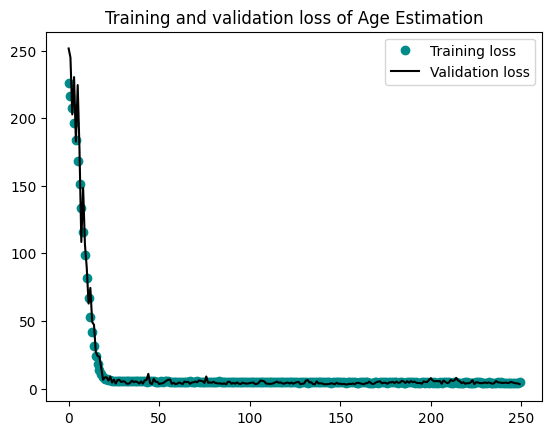

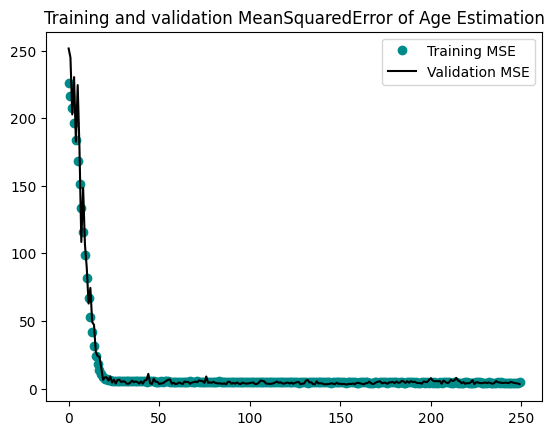

In [ ]:
loss = history.history['loss']
val_loss = history.history['val_loss']
mse = history.history['mse']
val_mse = history.history['val_mse']


epochs_x = range(len(loss))


# plt.plot(epochs_x, loss, 'go', label='Training loss')
plt.plot(epochs_x, loss, 'o', color ='darkcyan', label='Training loss')
plt.plot(epochs_x, val_loss, 'k', label='Validation loss')
plt.title('Training and validation loss of Age Estimation')
plt.legend()

plt.figure()
# plt.plot(epochs_x, mse, 'go', label='Training MSE')
plt.plot(epochs_x, mse, 'o', color ='darkcyan', label='Training MSE')
plt.plot(epochs_x, val_mse, 'k', label='Validation MSE')
plt.title('Training and validation MeanSquaredError of Age Estimation')
plt.legend()



plt.show()

In [ ]:
epochs_x

range(0, 250)

### Download the model


In [ ]:
os.makedirs('/content/gdrive/MyDrive/Tooth_Shap_GPT/Deep_tooth/Model', exist_ok=True)
model.save('/content/gdrive/MyDrive/Tooth_Shap_GPT/Deep_tooth/Model/Unflipped_Regress_Age(7-23)/1_Re_1e-4_250_Freeze.h5')

/usr/local/lib/python3.10/dist-packages/keras/src/engine/training.py:3079: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


## Test

###  Clone Efficient

In [ ]:
import os
%cd /content
if not os.path.isdir("efficientnet_keras_transfer_learning"):
 !git clone https://github.com/Wanita-8943/efficientnet_keras_transfer_learning
%cd efficientnet_keras_transfer_learning/

/content
Cloning into 'efficientnet_keras_transfer_learning'...
remote: Enumerating objects: 1100, done.
remote: Counting objects: 100% (263/263), done.
remote: Compressing objects: 100% (142/142), done.
remote: Total 1100 (delta 133), reused 241 (delta 121), pack-reused 837
Receiving objects: 100% (1100/1100), 14.10 MiB | 11.22 MiB/s, done.
Resolving deltas: 100% (630/630), done.
/content/efficientnet_keras_transfer_learning


### Load model

In [ ]:
import sys
sys.path.append('/content/gdrive/MyDrive/Tooth_Shap_GPT/Deep_tooth/Model/Unflipped_Regress_Age(7-23)/1_Re_1e-4_250_Freeze.h5')

from efficientnet.layers import Swish, DropConnect
from efficientnet.model import ConvKernalInitializer
from tensorflow.keras.utils import get_custom_objects

get_custom_objects().update({
    'ConvKernalInitializer': ConvKernalInitializer,
    'Swish': Swish,
    'DropConnect':DropConnect
})

In [ ]:
from tensorflow.keras.models import load_model
model = load_model('/content/gdrive/MyDrive/Tooth_Shap_GPT/Deep_tooth/Model/Unflipped_Regress_Age(7-23)/1_Re_1e-4_250_Freeze.h5')
height = width = model.input_shape[1]

### Prepare Data

In [ ]:
train = pd.read_csv (r'/content/gdrive/MyDrive/Tooth_Shap_GPT/Deep_tooth/Model/Unflipped_Multi_task(All)(7-23)/table_train_7_23_fold.csv')
train

,Unnamed: 0,Age(year),Gender,Folder_type,Folder_name,Path_Name,Filename,Fold,Gender_Class
0,0,7,F,Normal,Both,/content/gdrive/MyDrive/Tooth_Shap_GPT/Deep_to...,V1.jpg,2,0
1,1,7,F,Normal,Both,/content/gdrive/MyDrive/Tooth_Shap_GPT/Deep_to...,FlipV1.jpg,4,0
2,2,7,F,Normal,Both,/content/gdrive/MyDrive/Tooth_Shap_GPT/Deep_to...,V2.jpg,10,0
3,3,7,F,Normal,Both,/content/gdrive/MyDrive/Tooth_Shap_GPT/Deep_to...,FlipV2.jpg,9,0
4,4,7,F,Normal,Both,/content/gdrive/MyDrive/Tooth_Shap_GPT/Deep_to...,V3.jpg,10,0
...,...,...,...,...,...,...,...,...,...
3780,3780,23,M,Normal,Both,/content/gdrive/MyDrive/Tooth_Shap_GPT/Deep_to...,FlipE429.jpg,10,1
3781,3781,23,M,Normal,Both,/content/gdrive/MyDrive/Tooth_Shap_GPT/Deep_to...,E430.jpg,6,1
3782,3782,23,M,Normal,Both,/content/gdrive/MyDrive/Tooth_Shap_GPT/Deep_to...,FlipE430.jpg,10,1
3783,3783,23,M,Normal,Both,/content/gdrive/MyDrive/Tooth_Shap_GPT/Deep_to...,E431.jpg,10,1


In [ ]:
train = train.iloc[:,1:]

In [ ]:
DATA_PATH = "/content/gdrive/MyDrive/Tooth_Shap_GPT/Deep_tooth/Data_Cut_images"
os.chdir(DATA_PATH)
train_dir = os.path.join(DATA_PATH, 'Normal')
print(train_dir)
test_dir = os.path.join(DATA_PATH, 'Test')
print(test_dir)

/content/gdrive/MyDrive/Tooth_Shap_GPT/Deep_tooth/Data_Cut_images/Normal
/content/gdrive/MyDrive/Tooth_Shap_GPT/Deep_tooth/Data_Cut_images/Test


In [ ]:
batch_size = 16

from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_datagen = ImageDataGenerator(
      rescale=1./255, #โมเดลส่วนใหญ่ต้องใช้ RGB ในช่วง 0–1
      rotation_range=40,
      width_shift_range=0.2,
      height_shift_range=0.2,
      shear_range=0.2,
      zoom_range=0.2,
      # horizontal_flip=True,
      fill_mode='nearest')

# Note that the validation data should not be augmented!
test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_dataframe(
        dataframe = train,
        directory = train_dir,
        x_col = 'Path_Name',
        y_col = 'Age(year)',
        class_mode = 'raw',
        color_mode= 'rgb',
        target_size=(height, width), # รูปภาพทั้งหมดจะถูกปรับขนาดตามความสูงและความกว้างของเป้าหมาย
        batch_size=batch_size)

#label
#labels = (train_generator.class_indices)
#labels = dict((v,k) for k,v in labels.items())
#print(labels)

Found 3785 validated image filenames.


In [ ]:
test = pd.read_csv (r'/content/gdrive/MyDrive/Tooth_Shap_GPT/Deep_tooth/Model/Unflipped_Multi_task(All)(7-23)/table_test_7_23_forGender.csv')
test

,Unnamed: 0,Age(year),Gender,Folder_type,Folder_name,Path_Name,Filename,Gender_Class,Gender_Predict
0,0,7,F,Normal,Both,/content/gdrive/MyDrive/Tooth_Shap_GPT/Deep_to...,V69.jpg,0,Female
1,1,7,F,Normal,Both,/content/gdrive/MyDrive/Tooth_Shap_GPT/Deep_to...,FlipV69.jpg,0,Female
2,2,7,F,Normal,Both,/content/gdrive/MyDrive/Tooth_Shap_GPT/Deep_to...,V70.jpg,0,Female
3,3,7,F,Normal,Both,/content/gdrive/MyDrive/Tooth_Shap_GPT/Deep_to...,FlipV70.jpg,0,Female
4,4,7,F,Normal,Both,/content/gdrive/MyDrive/Tooth_Shap_GPT/Deep_to...,V74.jpg,0,Female
...,...,...,...,...,...,...,...,...,...
837,930,20,F,Abnormal,Rt,/content/gdrive/MyDrive/Tooth_Shap_GPT/Deep_to...,Q49.jpg,0,Female
838,931,20,M,Abnormal,Lt,/content/gdrive/MyDrive/Tooth_Shap_GPT/Deep_to...,FlipQ412.jpg,1,Male
839,932,21,M,Abnormal,Lt,/content/gdrive/MyDrive/Tooth_Shap_GPT/Deep_to...,FlipN379.jpg,1,Male
840,933,22,F,Abnormal,Rt,/content/gdrive/MyDrive/Tooth_Shap_GPT/Deep_to...,U136.jpg,0,Female


In [ ]:
test = test.iloc[:,1:]
test

,Age(year),Gender,Folder_type,Folder_name,Path_Name,Filename,Gender_Class,Gender_Predict
0,7,F,Normal,Both,/content/gdrive/MyDrive/Tooth_Shap_GPT/Deep_to...,V69.jpg,0,Female
1,7,F,Normal,Both,/content/gdrive/MyDrive/Tooth_Shap_GPT/Deep_to...,FlipV69.jpg,0,Female
2,7,F,Normal,Both,/content/gdrive/MyDrive/Tooth_Shap_GPT/Deep_to...,V70.jpg,0,Female
3,7,F,Normal,Both,/content/gdrive/MyDrive/Tooth_Shap_GPT/Deep_to...,FlipV70.jpg,0,Female
4,7,F,Normal,Both,/content/gdrive/MyDrive/Tooth_Shap_GPT/Deep_to...,V74.jpg,0,Female
...,...,...,...,...,...,...,...,...
837,20,F,Abnormal,Rt,/content/gdrive/MyDrive/Tooth_Shap_GPT/Deep_to...,Q49.jpg,0,Female
838,20,M,Abnormal,Lt,/content/gdrive/MyDrive/Tooth_Shap_GPT/Deep_to...,FlipQ412.jpg,1,Male
839,21,M,Abnormal,Lt,/content/gdrive/MyDrive/Tooth_Shap_GPT/Deep_to...,FlipN379.jpg,1,Male
840,22,F,Abnormal,Rt,/content/gdrive/MyDrive/Tooth_Shap_GPT/Deep_to...,U136.jpg,0,Female


### Predict

In [ ]:
act = test['Age(year)'].tolist() #ค่าจริง
path = test['Path_Name'].tolist() #path

In [ ]:
from tensorflow.keras.preprocessing import image

def predict_image(img_path):
    # Read the image and resize it
    img = image.load_img(img_path, target_size=(height, width)) #รูปทุกรูปมีขนาดไม่เท่ากันจึงตั้งไว้ว่าเวลาจะให้ model ดึงรูปมาทำนายให้ดึงรูปเข้ามาตามขนาดที่ตั้งไว้ตามพารามิตเตอร์
    # Convert it to a Numpy array with target shape.
    x = image.img_to_array(img)  #model ไม่สามารถทำนายรูปภาพโดยตรงได้ จึงเเปลงรูปภาพให้เป็น array เเล้วให้โมเดลทำนาย
    # Reshape
    x = x.reshape((1,) + x.shape) # เพิ่ม ไดเมนชั่นของโมเดล ให้เป็น 4 ได้ เมนชั่น โดยที่ 1, คือบอกให้โมเดลนำเข้าทีละ 1 รูปเเล้วค่อยทำนาย เเละ + ไดเมนชั่น คือ 150 ,150 ,3(สีของ RGB)
    x /= 255.
    result = model.predict([x])
    return result[0]

In [ ]:
predict_image(path[0])[0]

1/1 [==============================] - 10s 10s/step


6.9682865

In [ ]:
#Predict
pred_list = list()
prob_list = list()
img_path= path
for i in range(0,len(img_path)):
    predict = predict_image(img_path[i])
    result = predict[0]
    pred_list.append(result)
    # prob_list.append(predict[result])

In [ ]:
pred_list

In [ ]:
print(type(pred_list))

<class 'list'>


In [ ]:
pred_int = np.around(pred_list)

In [ ]:
#แปลงเป็น array
pred = np.array(pred_int)
act = np.array(act)

In [ ]:
pred

### confusion_matrix

In [ ]:
import numpy as np
from sklearn.metrics import confusion_matrix

# act = data_train['class'].array
# pred = data_train['category_ov'].array

cmat = confusion_matrix(act, pred)
print('classifier accuracy = {}%'.format((100.*np.trace(cmat))/(np.sum(cmat))))

#Marking the Confusion Matrix
from sklearn.metrics import classification_report,confusion_matrix
print(classification_report(act, pred))#performance

classifier accuracy = 24.346793349168646%
              precision    recall  f1-score   support

         5.0       0.00      0.00      0.00         0
         6.0       0.00      0.00      0.00         0
         7.0       0.63      0.34      0.44        50
         8.0       0.19      0.23      0.21        48
         9.0       0.30      0.42      0.35        50
        10.0       0.37      0.39      0.38        49
        11.0       0.41      0.42      0.42        50
        12.0       0.35      0.35      0.35        48
        13.0       0.33      0.32      0.33        50
        14.0       0.18      0.28      0.21        47
        15.0       0.22      0.22      0.22        51
        16.0       0.19      0.28      0.23        50
        17.0       0.11      0.12      0.12        51
        18.0       0.14      0.16      0.15        50
        19.0       0.17      0.24      0.20        49
        20.0       0.15      0.16      0.16        49
        21.0       0.16      0.10      

/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Recall and F-score are ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Recall and F-score are ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Recall and F-score are ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


Text(0.5, 76.24999999999999, 'Predicted label')

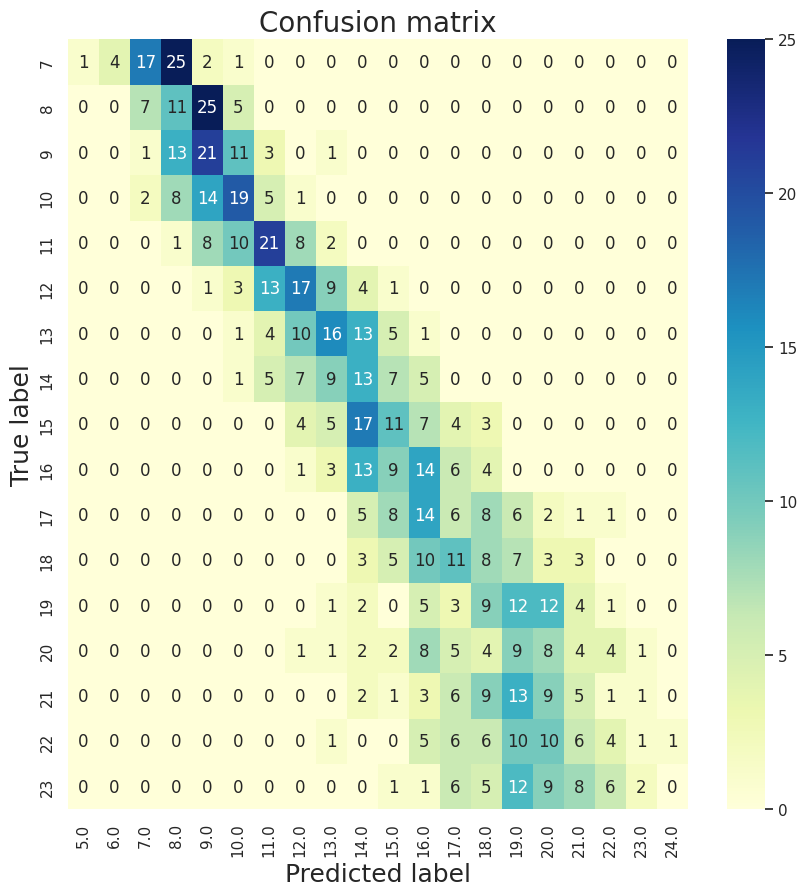

In [ ]:
#create CF
data = {'Actual': act,'Predicted' : pred}
df = pd.DataFrame(data, columns=['Actual','Predicted'])
conf_mat = pd.crosstab(df['Actual'],df['Predicted'],rownames=['Actual'],colnames=['Predicted'])

#Confusion matrix
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
cm = confusion_matrix(act, pred)

#plot Confusion matrix
import seaborn as sns
sns.set()
fig, ax = plt.subplots(figsize=(10, 10))

ax = sns.heatmap(conf_mat, annot=True, fmt="d", cmap="YlGnBu") #Blues,Oranges,Reds
ax.set_title('Confusion matrix',fontsize=20)
ax.set_ylabel('True label',fontsize=18)
ax.set_xlabel('Predicted label',fontsize=18)

### MSE and MAE

In [ ]:
from sklearn.metrics import mean_absolute_error,mean_squared_error

mae = mean_absolute_error(act,pred)
mse = mean_squared_error(act,pred)
rmse = mean_squared_error(act,pred,squared=False)

print("MAE:",mae)
print("MSE:",mse)
print("RMSE:",rmse)

MAE: 1.504750593824228
MSE: 4.4002375296912115
RMSE: 2.097674314494796


In [ ]:
from sklearn.metrics import r2_score
 # Defines aggregating of multiple output scores. Array-like value defines weights used to average scores. Default is “uniform_average
print("R-squared:", r2_score(act, pred, multioutput= 'uniform_average'))
# Returns a full set of scores in case of multioutput input.
print("R-squared:", r2_score(act, pred, multioutput= 'raw_values'))
# Scores of all outputs are averaged, weighted by the variances of each individual output
print("R-squared:", r2_score(act, pred, multioutput= 'variance_weighted'))

R-squared: 0.8167517692860714
R-squared: [0.81675177]
R-squared: 0.8167517692860714


## DeeptoothDuo  
  
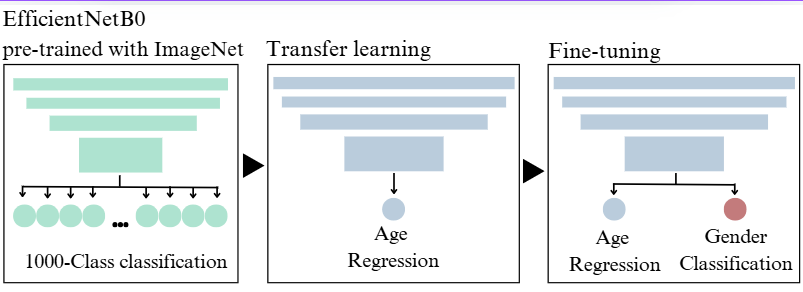


### Clone Efficient

In [ ]:
#ดึงข้อมูลใน Github มาใช้
import os
%cd /content
if not os.path.isdir("efficientnet_keras_transfer_learning"):
 !git clone https://github.com/Wanita-8943/efficientnet_keras_transfer_learning
%cd efficientnet_keras_transfer_learning/


/content
/content/efficientnet_keras_transfer_learning


### Load Model

In [ ]:
import sys
sys.path.append('/content/gdrive/MyDrive/Tooth_Shap_GPT/Deep_tooth/Model/Multi_task(Age)(7-25)/16_Multi_8e-6_250_Unfreeze.h5')

from efficientnet.layers import Swish, DropConnect
from efficientnet.model import ConvKernalInitializer
from tensorflow.keras.utils import get_custom_objects

get_custom_objects().update({
    'ConvKernalInitializer': ConvKernalInitializer,
    'Swish': Swish,
    'DropConnect':DropConnect
})


In [ ]:
from tensorflow.keras.models import load_model
model = tf.keras.models.load_model("/content/gdrive/MyDrive/Tooth_Shap_GPT/Deep_tooth/Model/Multi_task(Age)(7-25)/16_Multi_8e-6_250_Unfreeze.h5")
model.summary()

Model: "model"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_1 (InputLayer)        [(None, 224, 224, 3)]        0         []                            
                                                                                                  
 conv2d (Conv2D)             (None, 112, 112, 32)         864       ['input_1[0][0]']             
                                                                                                  
 batch_normalization (Batch  (None, 112, 112, 32)         128       ['conv2d[0][0]']              
 Normalization)                                                                                   
                                                                                                  
 swish (Swish)               (None, 112, 112, 32)         0         ['batch_normalization[0][0

### Age estimation

#### confusion_matrix

In [ ]:
import numpy as np
from sklearn.metrics import confusion_matrix

# act = data_train['class'].array
# pred = data_train['category_ov'].array

cmat = confusion_matrix(act_age, age_predict)
print('classifier accuracy = {}%'.format((100.*np.trace(cmat))/(np.sum(cmat))))

#Marking the Confusion Matrix
from sklearn.metrics import classification_report,confusion_matrix
print(classification_report(act_age, age_predict))#performance

classifier accuracy = 30.858960763520678%
              precision    recall  f1-score   support

           7       0.97      0.70      0.81        50
           8       0.49      0.71      0.58        48
           9       0.43      0.64      0.52        50
          10       0.38      0.37      0.37        49
          11       0.45      0.38      0.41        50
          12       0.38      0.42      0.40        48
          13       0.48      0.48      0.48        50
          14       0.27      0.34      0.30        47
          15       0.20      0.22      0.21        51
          16       0.31      0.22      0.26        50
          17       0.27      0.33      0.30        51
          18       0.15      0.22      0.18        50
          19       0.15      0.22      0.18        49
          20       0.11      0.14      0.12        49
          21       0.18      0.32      0.23        50
          22       0.13      0.12      0.12        50
          23       0.11      0.02      

Text(0.5, 76.24999999999999, 'Predicted label')

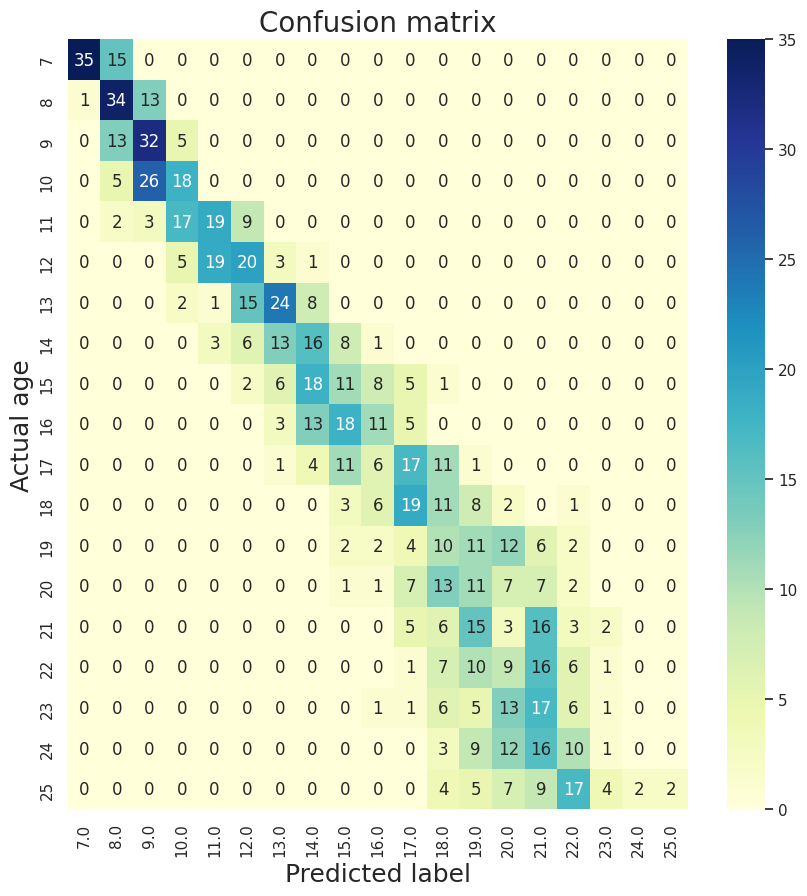

In [ ]:
#create CF
data = {'Actual': act_age,'Predicted' : age_predict}
df = pd.DataFrame(data, columns=['Actual','Predicted'])
conf_mat = pd.crosstab(df['Actual'],df['Predicted'],rownames=['Actual'],colnames=['Predicted'])

#Confusion matrix
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
cm = confusion_matrix(act_age, age_predict)

#plot Confusion matrix
import seaborn as sns
sns.set()
fig, ax = plt.subplots(figsize=(10, 10))

ax = sns.heatmap(conf_mat, annot=True, fmt="d", cmap="YlGnBu") #Blues,Oranges,Reds
ax.set_title('Confusion matrix',fontsize=20)
ax.set_ylabel('Actual age',fontsize=18)
ax.set_xlabel('Predicted label',fontsize=18)

#### MSE and MAE

In [ ]:
from sklearn.metrics import mean_absolute_error,mean_squared_error

mae = mean_absolute_error(act_age,age_predict)
mse = mean_squared_error(act_age,age_predict)
rmse = mean_squared_error(act_age,age_predict,squared=False)

print("MAE:",mae)
print("MSE:",mse)
print("RMSE:",rmse)

MAE: 1.3637327677624602
MSE: 3.83457051961824
RMSE: 1.958205944128002


#### R-squared (coefficient of determination)

In [ ]:
from sklearn.metrics import r2_score
 # Defines aggregating of multiple output scores. Array-like value defines weights used to average scores. Default is “uniform_average
print("R-squared:", r2_score(act_age, age_predict, multioutput= 'uniform_average'))
# Returns a full set of scores in case of multioutput input.
print("R-squared:", r2_score(act_age, age_predict, multioutput= 'raw_values'))
# Scores of all outputs are averaged, weighted by the variances of each individual output
print("R-squared:", r2_score(act_age, age_predict, multioutput= 'variance_weighted'))

R-squared: 0.8723684294250963
R-squared: [0.87236843]
R-squared: 0.8723684294250963


### Gender Prediction

In [ ]:
gender_predict_str = []
# ใช้ลูป for เพื่อแปลงค่าและเพิ่มเข้าใน NumPy array
for value in list_Classification_predict:
    if value >= 0.5:
        gender_predict_str = np.append(gender_predict_str, 'Male')
    else:
        gender_predict_str = np.append(gender_predict_str, 'Female')

# แสดงผลลัพธ์
print(gender_predict_str)

In [ ]:
gender_predict_int = []
# ใช้ลูป for เพื่อแปลงค่าและเพิ่มเข้าใน NumPy array
for value in list_Classification_predict:
    if value >= 0.5:
        gender_predict_int = np.append(gender_predict_int, 1)
    else:
        gender_predict_int = np.append(gender_predict_int, 0)

# แสดงผลลัพธ์
print(gender_predict_int)

In [ ]:
gender_predict_str # array str
act_gender_str = np.array(test['Gender_Predict'].tolist())

gender_predict_int # array int
act_gender_int = np.array(test['Gender_Class'].tolist()) #ค่าจริง

#### confusion_matrix

In [ ]:
import numpy as np
from sklearn.metrics import confusion_matrix

# act = data_train['class'].array
# pred = data_train['category_ov'].array

cmat = confusion_matrix(act_gender_str, gender_predict_str)
print('classifier accuracy = {}%'.format((100.*np.trace(cmat))/(np.sum(cmat))))

#Marking the Confusion Matrix
from sklearn.metrics import classification_report,confusion_matrix
print(classification_report(act_gender_str, gender_predict_str))#performance

classifier accuracy = 87.38069989395547%
              precision    recall  f1-score   support

      Female       0.88      0.87      0.87       475
        Male       0.87      0.88      0.87       468

    accuracy                           0.87       943
   macro avg       0.87      0.87      0.87       943
weighted avg       0.87      0.87      0.87       943



Text(0.5, 76.24999999999999, 'Predicted label')

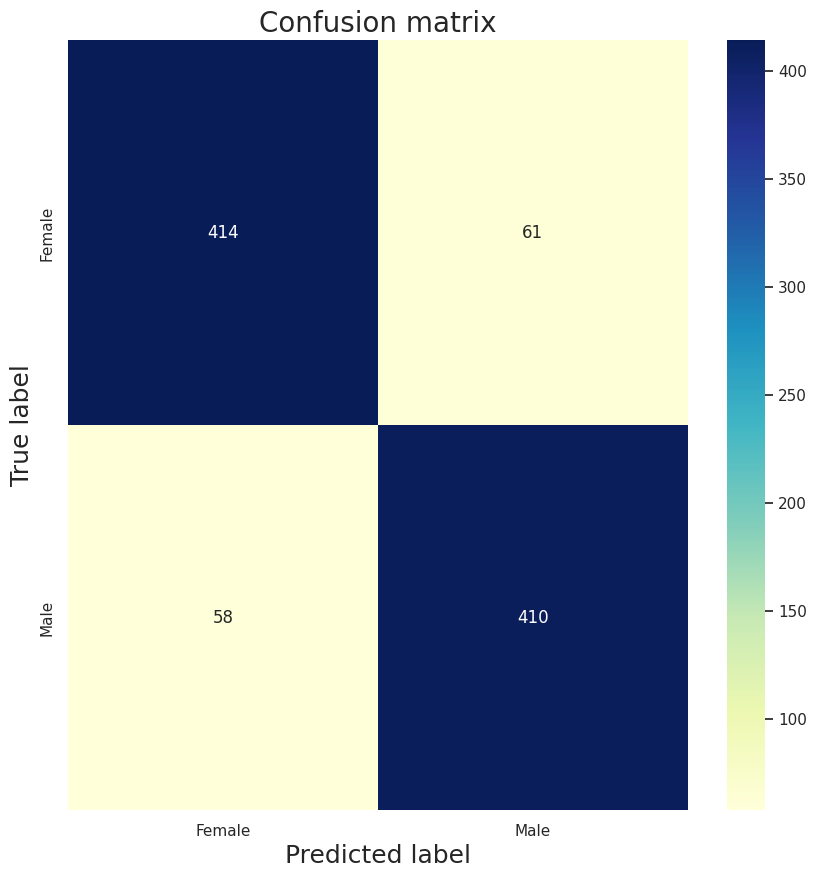

In [ ]:
#create CF
data = {'Actual': act_gender_str,'Predicted' : gender_predict_str}
df = pd.DataFrame(data, columns=['Actual','Predicted'])
conf_mat = pd.crosstab(df['Actual'],df['Predicted'],rownames=['Actual'],colnames=['Predicted'])

#Confusion matrix
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
cm = confusion_matrix(act_gender_str, gender_predict_str)

#plot Confusion matrix
import seaborn as sns
sns.set()
fig, ax = plt.subplots(figsize=(10, 10))

ax = sns.heatmap(conf_mat, annot=True, fmt="d", cmap="YlGnBu") #Blues,Oranges,Reds
ax.set_title('Confusion matrix',fontsize=20)
ax.set_ylabel('True label',fontsize=18)
ax.set_xlabel('Predicted label',fontsize=18)

#### MSE and MAE

In [ ]:
from sklearn.metrics import mean_absolute_error,mean_squared_error

mae = mean_absolute_error(act_gender_int,gender_predict_int)
mse = mean_squared_error(act_gender_int,gender_predict_int)
rmse = mean_squared_error(act_gender_int,gender_predict_int,squared=False)

print("MAE:",mae)
print("MSE:",mse)
print("RMSE:",rmse)

MAE: 0.1261930010604454
MSE: 0.1261930010604454
RMSE: 0.35523654240582486


# YOLO Object detection model  


 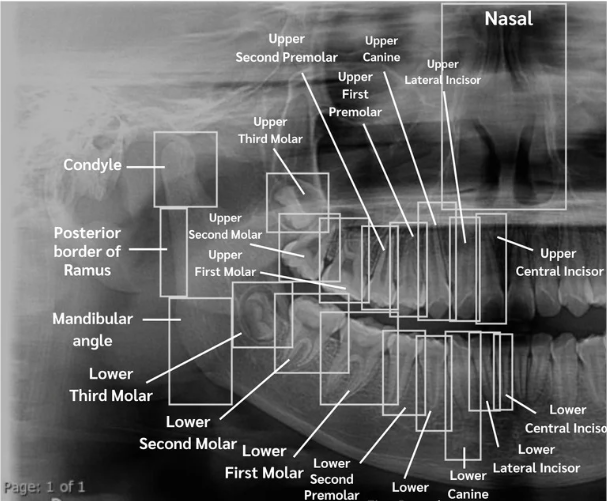

In [ ]:
# load YOLO ที่Train มา
# Replace with code to load your trained YOLO model
weights_path = '/content/gdrive/MyDrive/Tooth_Shap_GPT/papers/gpt/Yolo_v5/best.pt'

# Load YOLOv5 model from Google Drive
yolo_model = torch.hub.load('ultralytics/yolov5', 'custom', path=weights_path)

Using cache found in /root/.cache/torch/hub/ultralytics_yolov5_master
YOLOv5 🚀 2024-6-14 Python-3.10.12 torch-2.3.0+cu121 CUDA:0 (Tesla T4, 15102MiB)

Fusing layers... 
Model summary: 157 layers, 7064065 parameters, 0 gradients, 15.9 GFLOPs
Adding AutoShape... 


## Test

In [ ]:
!python val.py --data /content/gdrive/MyDrive/Yolo/yaml/tooth2.yaml --task test --weights /content/yolov5/runs/train/exp/weights/best.pt --img 640 --conf 0.25

val: data=/content/gdrive/MyDrive/Yolo/yaml/tooth2.yaml, weights=['/content/yolov5/runs/train/exp/weights/best.pt'], batch_size=32, imgsz=640, conf_thres=0.25, iou_thres=0.6, max_det=300, task=test, device=, workers=8, single_cls=False, augment=False, verbose=False, save_txt=False, save_hybrid=False, save_conf=False, save_json=False, project=runs/val, name=exp, exist_ok=False, half=False, dnn=False
WARNING ⚠️ confidence threshold 0.25 > 0.001 produces invalid results
YOLOv5 🚀 v7.0-278-g050c72c Python-3.10.12 torch-2.1.0+cu121 CUDA:0 (Tesla T4, 15102MiB)

Fusing layers... 
Model summary: 157 layers, 7064065 parameters, 0 gradients, 15.9 GFLOPs
test: Scanning /content/gdrive/MyDrive/Yolo/Custom_Vision_data/Test0_0... 212 images, 0 backgrounds, 0 corrupt: 100% 212/212 [00:06<00:00, 33.38it/s] 
test: New cache created: /content/gdrive/MyDrive/Yolo/Custom_Vision_data/Test0_0.cache
                 Class     Images  Instances          P          R      mAP50   mAP50-95: 100% 7/7 [00:13<00:00

/content/yolov5


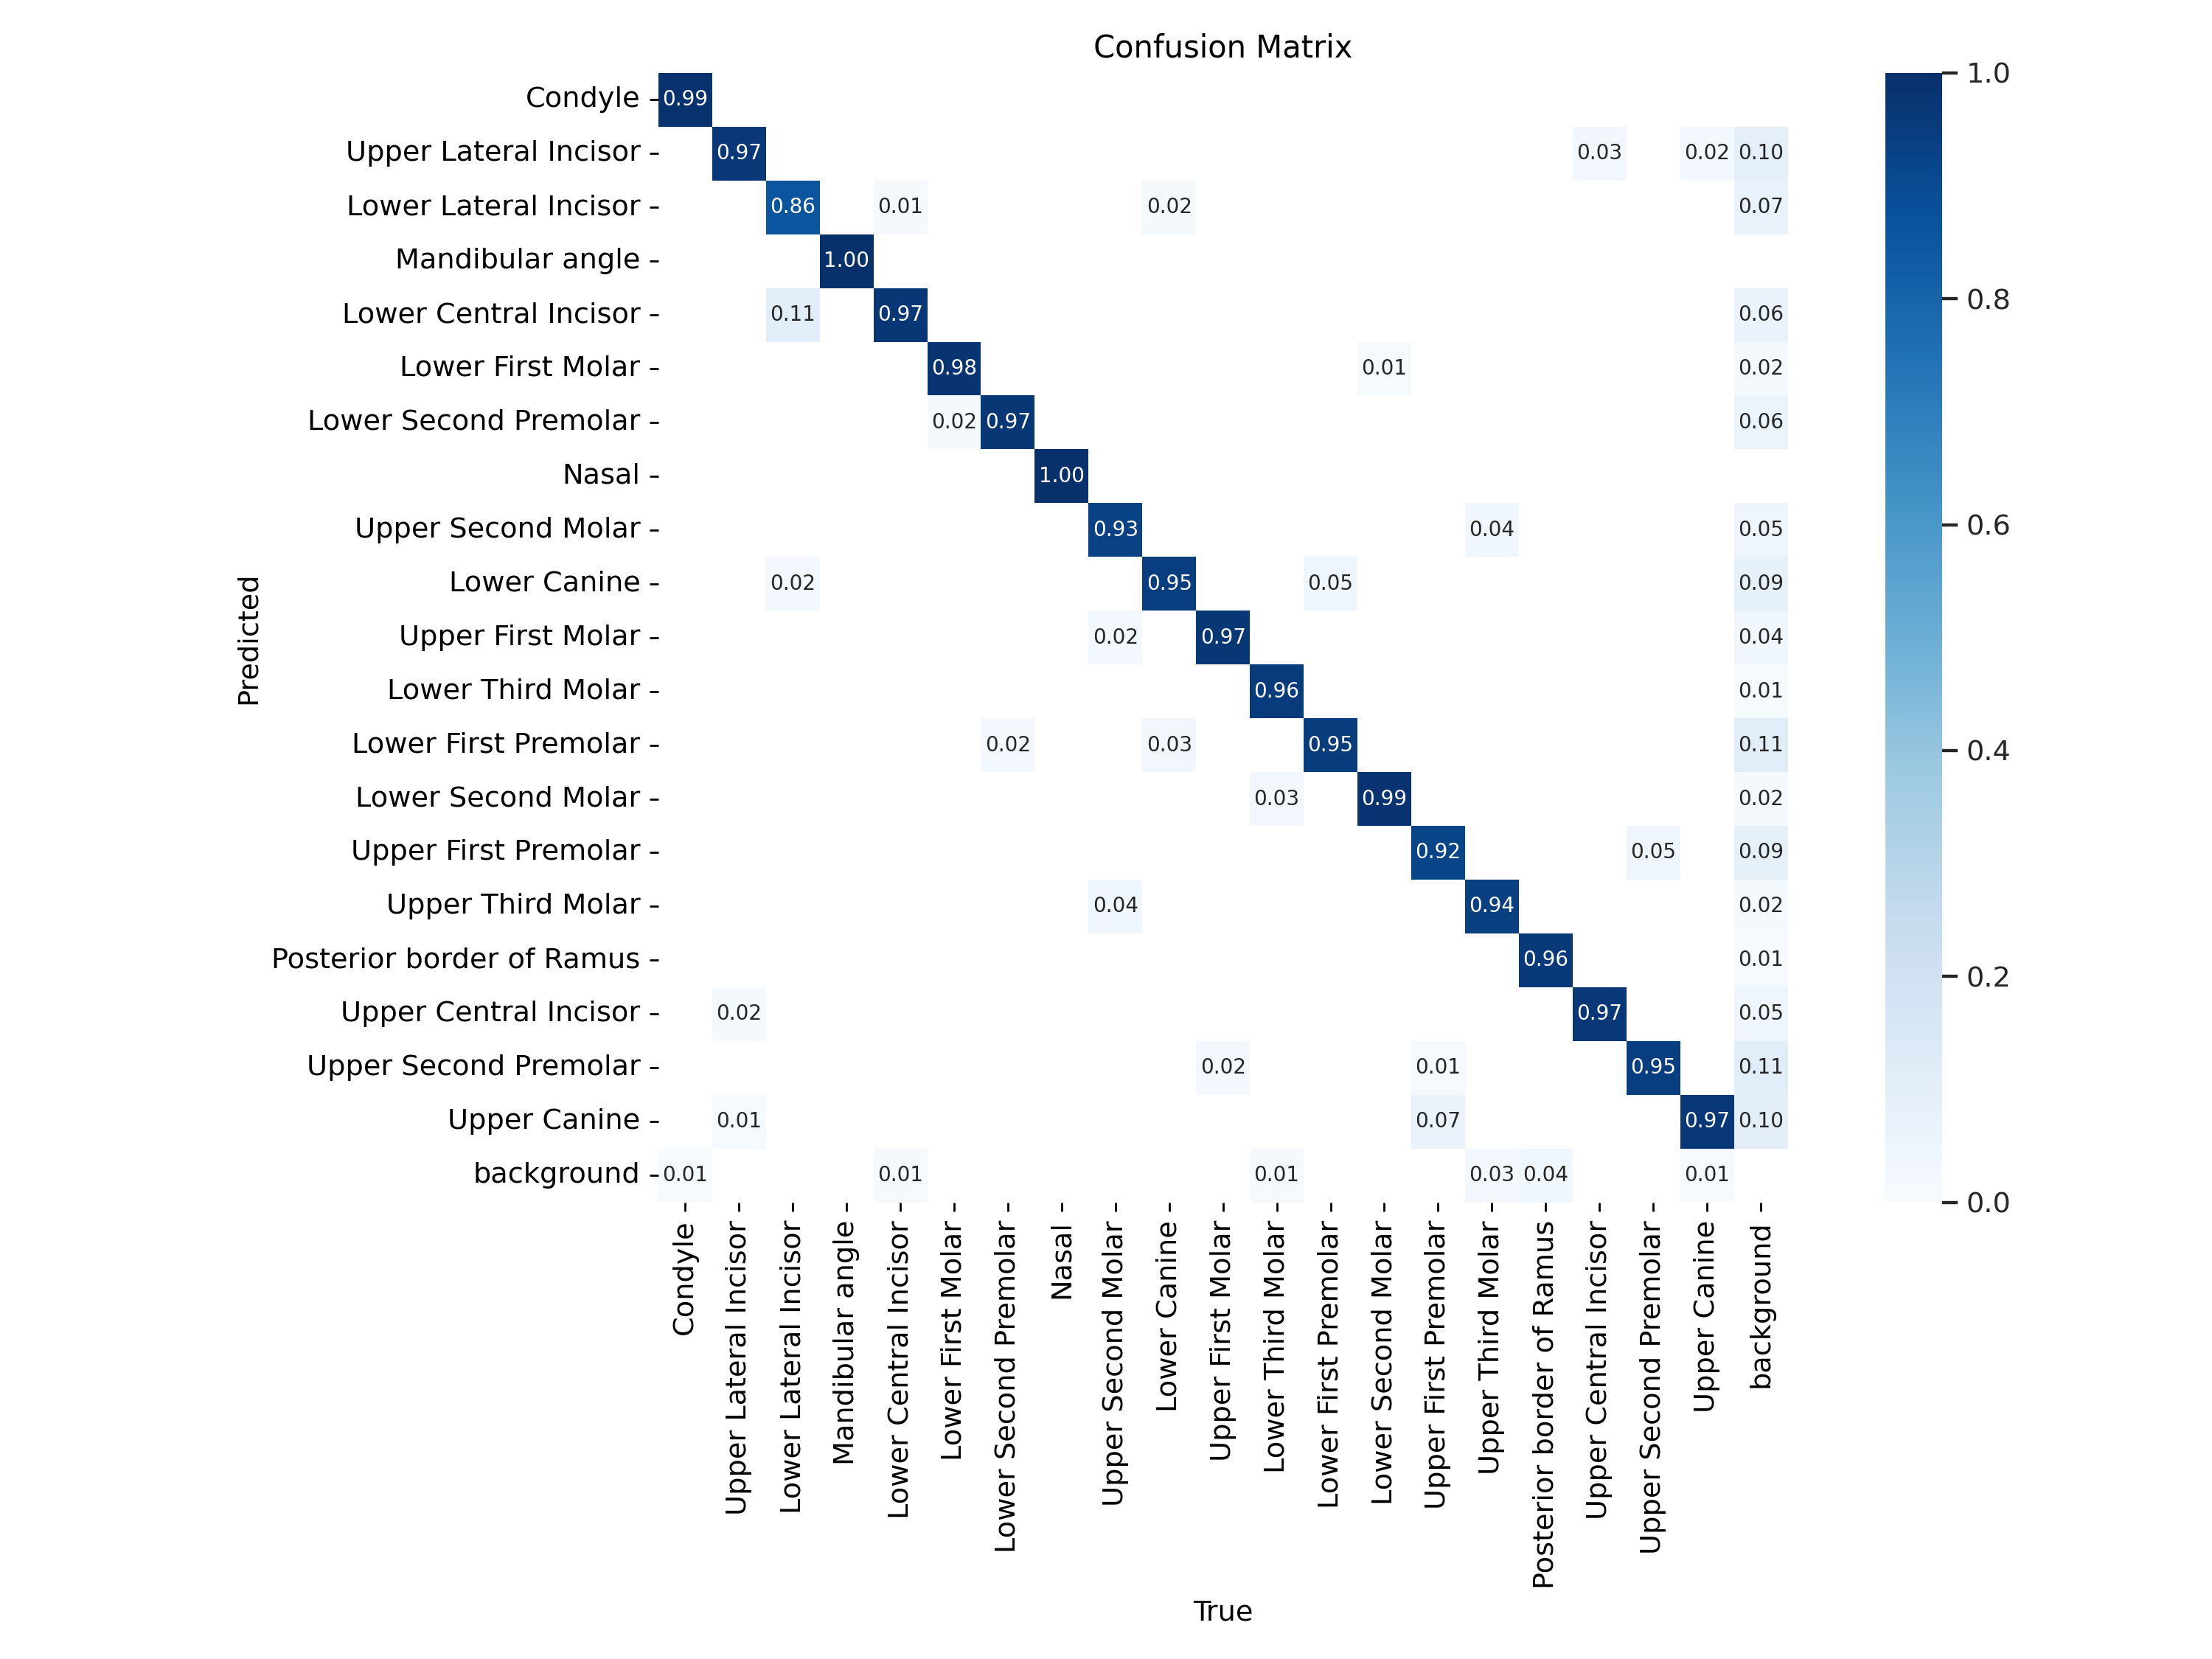

In [ ]:
%cd /content/yolov5
Image(filename=f'/content/yolov5/runs/val/exp2/confusion_matrix.png', width=1200)

# Domain-specific Explainable AI (XAI)  

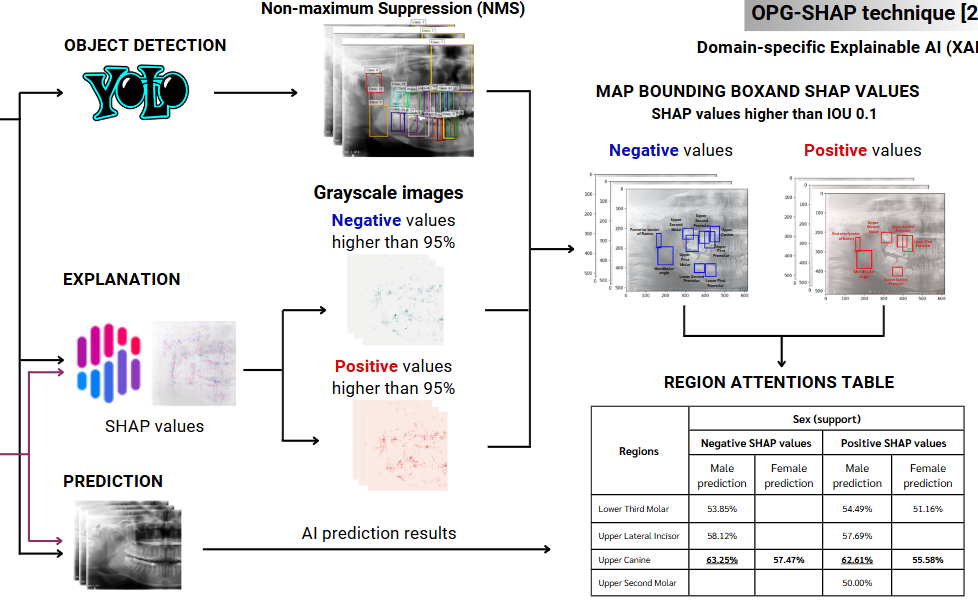

## Create background

In [ ]:
def process_input(dt_train):
    # Initialize an empty list to store background data
    background_data = []

    # Ensure 'Path_Name' column exists in the DataFrame
    if 'Path_Name' not in dt_train.columns:
        raise ValueError("The 'Path_Name' column does not exist in the DataFrame.")

    # Loop to preprocess and create the background data
    for i in range(len(dt_train)):
        print(f"Processing image {i+1}/{len(dt_train)}")
        # Get the image path from the DataFrame
        image_path = dt_train['Path_Name'].iloc[i]  # Use .iloc to access rows by integer index
        # Load and preprocess the image
        image = load_img(image_path, target_size=(224, 224))  # Adjust target_size
        preprocessed_image = img_to_array(image) / 255.0  # Normalize pixel values

        # Add the preprocessed image to the background_data list
        background_data.append(preprocessed_image)

    return background_data

##**แปลง Bg dataเป็น array เพื่อใช้ในการคำนวณค่า SHAP**

In [ ]:
background_train_array = np.array(background_train)
background_test_array = np.array(background_test)

In [ ]:
print(len(background_train_array))
print(background_train_array.shape)
print(background_test_array.shape)

2660
(2660, 224, 224, 3)
(943, 224, 224, 3)


## คำนวณ SHAP Values

### load model

#### Import

In [ ]:
import os
import numpy as np
import pandas as pd
#import efficientnet.tfkeras
import tensorflow as tf
from tensorflow.keras.applications import EfficientNetB0

#### Clone Efficient

In [ ]:
#ดึงข้อมูลใน Github มาใช้
import os
%cd /content
if not os.path.isdir("efficientnet_keras_transfer_learning"):
 !git clone https://github.com/Wanita-8943/efficientnet_keras_transfer_learning
%cd efficientnet_keras_transfer_learning/


/content
/content/efficientnet_keras_transfer_learning


#### Load Model

In [ ]:
import sys
sys.path.append('/content/gdrive/MyDrive/Tooth_Shap_GPT/Deep_tooth/Model/Multi_task(Age)(7-25)/16_Multi_8e-6_250_Unfreeze.h5')

from efficientnet.layers import Swish, DropConnect
from efficientnet.model import ConvKernalInitializer
from tensorflow.keras.utils import get_custom_objects

get_custom_objects().update({
    'ConvKernalInitializer': ConvKernalInitializer,
    'Swish': Swish,
    'DropConnect':DropConnect
})


In [ ]:
from tensorflow.keras.models import load_model
model = tf.keras.models.load_model("/content/gdrive/MyDrive/Tooth_Shap_GPT/Deep_tooth/Model/Multi_task(Age)(7-25)/16_Multi_8e-6_250_Unfreeze.h5")
model.summary()

In [ ]:
height = width = model.input_shape[1]
print(f"height: {height}, width: {width}")

height: 224, width: 224


In [ ]:
# Check the number of output units in the final layer
num_output_units = model.layers[-1].output_shape[-1]

# Check if it's a binary classification model (2 output units) or not
if num_output_units == 2:
    print("This is a binary classification model.")
else:
    print("This is not a binary classification model.")

This is not a binary classification model.


## SHAP & YOLO

### SHAP

In [ ]:
!pip install shap==0.44.1

In [ ]:
import shap

In [ ]:
print(background_test_array.shape)
print(background_test_array[[10]].shape) # ภาพที่ 10

(943, 224, 224, 3)
(1, 224, 224, 3)


เลือกเฉพาะ Output layer ไปทำการหาความสำคัญ

In [ ]:
import shap
import tensorflow as tf

# Create separate models for each output you want to explain
#AGE
model_layer1 = tf.keras.Model(inputs=model.input, outputs=model.get_layer('prediction_layer').output)
#Gender
model_layer2 = tf.keras.Model(inputs=model.input, outputs=model.get_layer('prediction_layer2').output)


In [ ]:
# Define your explainer for the first output layer (prediction_layer)
#AGE
explainer_layer1 = shap.GradientExplainer(model_layer1, background_train_array)

In [ ]:
# Define your explainer for the second output layer (prediction_layer2)
#Gender
explainer_layer2 = shap.GradientExplainer(model_layer2, background_train_array)

### yolo

In [ ]:
# load YOLO ที่Train มา
# Replace with code to load your trained YOLO model
weights_path = '/content/gdrive/MyDrive/Tooth_Shap_GPT/papers/gpt/Yolo_v5/best.pt'

# Load YOLOv5 model from Google Drive
yolo_model = torch.hub.load('ultralytics/yolov5', 'custom', path=weights_path)

Using cache found in /root/.cache/torch/hub/ultralytics_yolov5_master
YOLOv5 🚀 2024-6-14 Python-3.10.12 torch-2.3.0+cu121 CUDA:0 (Tesla T4, 15102MiB)

Fusing layers... 
Model summary: 157 layers, 7064065 parameters, 0 gradients, 15.9 GFLOPs
Adding AutoShape... 


#### ทํา non maximum suppression

In [ ]:
# กำหนด confidence
import pandas as pd

def compute_iou(boxA, boxB):
    # Determine the coordinates of the intersection rectangle
    xA = max(boxA[0], boxB[0])
    yA = max(boxA[1], boxB[1])
    xB = min(boxA[2], boxB[2])
    yB = min(boxB[3], boxB[3])

    # Compute the area of intersection
    interArea = max(0, xB - xA + 1) * max(0, yB - yA + 1)

    # Compute the area of both the prediction and ground-truth rectangles
    boxAArea = (boxA[2] - boxA[0] + 1) * (boxA[3] - boxA[1] + 1)
    boxBArea = (boxB[2] - boxB[0] + 1) * (boxB[3] - boxB[1] + 1)

    # Compute the intersection over union by taking the intersection
    # area and dividing it by the sum of prediction + ground-truth
    # areas - the intersection area
    iou = interArea / float(boxAArea + boxBArea - interArea)

    return iou

def nms_per_class(df, iou_threshold=0.5, confidence_threshold=0.6):
    # Initialize an empty DataFrame to store NMS results
    df_nms = pd.DataFrame()

    # Get unique class IDs
    class_ids = df['class'].unique()

    for class_id in class_ids:
        # Filter detections by class
        df_class = df[df['class'] == class_id].copy()

        # Filter out detections with low confidence
        df_class = df_class[df_class['confidence'] > confidence_threshold]

        # Apply NMS
        df_class_sorted = df_class.sort_values(by='confidence', ascending=False).reset_index(drop=True)
        suppressed_indices = set()

        for i in range(len(df_class_sorted)):
            if i in suppressed_indices:
                continue

            for j in range(i+1, len(df_class_sorted)):
                if j in suppressed_indices:
                    continue

                boxA = df_class_sorted.iloc[i][['xmin', 'ymin', 'xmax', 'ymax']]
                boxB = df_class_sorted.iloc[j][['xmin', 'ymin', 'xmax', 'ymax']]

                if compute_iou(boxA, boxB) > iou_threshold:
                    suppressed_indices.add(j)

        # Filter out suppressed detections
        df_nms_class = df_class_sorted.drop(index=list(suppressed_indices)).reset_index(drop=True)

        # Append results for this class to the main DataFrame
        df_nms = pd.concat([df_nms, df_nms_class], ignore_index=True)

    return df_nms

#### def map box ที่ detectกับ SHAP value

##### pos img

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import pandas as pd
from PIL import Image
import numpy as np

def plot_bboxes_on_image_pos(image_path, df, grayscale_image, output_path):
    selected_bboxes = []  #สร้าง list ว่าง มาเก็บกล่องที่มีค่า SHAP เกิน IoU ที่ 0.1
    # value_than_IoU = []

    # Load the original image
    img = Image.open(image_path) #  เปิดภาพจาก path
    img_array = np.array(img)

    # Get the image dimensions
    image_width, image_height = img.size

    # Create figure and axes
    fig, ax = plt.subplots()  #plot ภาพ + กล่อง

    # Display the original image
    ax.imshow(img)

    # Overlay the grayscale image with transparency // plot จากสีเทา ให้เป้นน สีแดง ทับลงไป
    ax.imshow(grayscale_image, cmap='Reds', alpha=0.6, extent=[0, image_width, image_height, 0])

    # Iterate over rows in the DataFrame
    for index, row in df.iterrows():  #df ที่ตัวแบบทนายมาทั้งหมด  จะทำการ loop เก็บค่าตห.จากตาราง
        xmin, ymin, xmax, ymax = row['xmin'], row['ymin'], row['xmax'], row['ymax']
        confidence, class_label,class_name = row['confidence'], row['class'],row['name']     #,IoU,row['iou']

        # Convert coordinates to absolute values // เปลี่ยนจากตห.ของกล่อง ให้ตามขนาดภาพที่ใส่เข้าไป (ม้้ง)
        abs_xmin = xmin * image_width
        abs_ymin = ymin * image_height
        abs_width = (xmax - xmin) * image_width
        abs_height = (ymax - ymin) * image_height

        # Map bounding box to the grayscale image //คำนวณบริเวณที่สินใจ
        # Calculate the region of interest in the grayscale image
        roi_xmin = int(xmin * grayscale_image.shape[1]) # แปลงพิกัดกรอบสีเหลี่ยมให้เข้ากับขนาดรูปภาพ โดย *พิกัด กับขนาดของ grayscale_image
        roi_ymin = int(ymin * grayscale_image.shape[0])
        roi_xmax = int(xmax * grayscale_image.shape[1])
        roi_ymax = int(ymax * grayscale_image.shape[0])

        # Extract the region of interest from the grayscale image
        roi = grayscale_image[roi_ymin:roi_ymax, roi_xmin:roi_xmax] # เลือก roi บริเวณที่สนใจ  จากgrayscale_image โดยตัด roi ออกมาเป็น nparray

        # Calculate the percentage of nonzero pixels
        nonzero_percentage = np.count_nonzero(roi) / (roi.shape[0] * roi.shape[1]) #Calculate the percentage ของ pixels ที่ไม่เป็น 0 แล้วหารด้วย pixels ทั้งหมด

        # If the percentage of nonzero pixels exceeds 10%, collect the bounding box
        if nonzero_percentage > 0.1:
            # Add bounding box information to the selected_bboxes list
            selected_bboxes.append({'xmin': abs_xmin, 'ymin': abs_ymin,'xmax': abs_xmin + abs_width, 'ymax': abs_ymin + abs_height,
                                    'confidence': confidence, 'class': class_label,'name':class_name}) #, 'iou':IoU
            # value_than_IoU.append(nonzero_percentage)

            # Create a rectangle patch //สร้างกล่อง
            rect = patches.Rectangle(
                (abs_xmin, abs_ymin), #abs แปลงเป็นพิกัดในหน่วย  pixel ให้ตรงกับขนาดภาพจริง
                abs_width,
                abs_height,
                linewidth=2,
                edgecolor='r', # เปลี่ยนสีกล่อง
                facecolor='none'  # Set facecolor to 'none' for an unfilled rectangle
            )

            # Add the rectangle to the axes
            ax.add_patch(rect)
            # Add confidence and class label as text
            text = f'Class: {class_label}' # ข้อความที่จะ Plot บนกล่อง
            #\nConfidence: {confidence:.2f}'
            plt.text(abs_xmin, abs_ymin - 10, text, color='black', fontsize=8, bbox=dict(facecolor='white', alpha=0.5)) # ตห + สีของตัวอักษร ขนาด front
    # Save the figure
    plt.savefig(output_path, bbox_inches='tight')

    # Show the plot
    plt.show()

    return selected_bboxes#, value_than_IoU

##### neg img

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import pandas as pd
from PIL import Image
import numpy as np

def plot_bboxes_on_image_neg(image_path, df, grayscale_image, output_path):
    selected_bboxes = []
    # value_than_IoU = []

    # Load the original image
    img = Image.open(image_path)
    img_array = np.array(img)

    # Get the image dimensions
    image_width, image_height = img.size

    # Create figure and axes
    fig, ax = plt.subplots()

    # Display the original image
    ax.imshow(img)

    # Overlay the grayscale image with transparency
    ax.imshow(grayscale_image, cmap='Blues', alpha=0.6, extent=[0, image_width, image_height, 0])

    # Iterate over rows in the DataFrame
    for index, row in df.iterrows():
        xmin, ymin, xmax, ymax = row['xmin'], row['ymin'], row['xmax'], row['ymax']
        confidence, class_label,class_name = row['confidence'], row['class'],row['name'] #,IoU,row['iou']

        # Convert coordinates to absolute values
        abs_xmin = xmin * image_width
        abs_ymin = ymin * image_height
        abs_width = (xmax - xmin) * image_width
        abs_height = (ymax - ymin) * image_height

        # Map bounding box to the grayscale image
        # Calculate the region of interest in the grayscale image
        roi_xmin = int(xmin * grayscale_image.shape[1])
        roi_ymin = int(ymin * grayscale_image.shape[0])
        roi_xmax = int(xmax * grayscale_image.shape[1])
        roi_ymax = int(ymax * grayscale_image.shape[0])

        # Extract the region of interest from the grayscale image
        roi = grayscale_image[roi_ymin:roi_ymax, roi_xmin:roi_xmax]

        # Calculate the percentage of nonzero pixels
        nonzero_percentage = np.count_nonzero(roi) / (roi.shape[0] * roi.shape[1])

        # If the percentage of nonzero pixels exceeds 10%, collect the bounding box#เลือกกล่องที่มีค่า shap ในกล่องมากกว่า 10% ของทั้งหมด
        if nonzero_percentage > 0.1:
            # Add bounding box information to the selected_bboxes list
            selected_bboxes.append({'xmin': abs_xmin, 'ymin': abs_ymin,'xmax': abs_xmin + abs_width, 'ymax': abs_ymin + abs_height,
                                    'confidence': confidence, 'class': class_label,'name':class_name}) #, 'iou':IoU
            # value_than_IoU.append(nonzero_percentage)

            # Create a rectangle patch
            rect = patches.Rectangle(
                (abs_xmin, abs_ymin),
                abs_width,
                abs_height,
                linewidth=2,
                edgecolor='b',
                facecolor='none'  # Set facecolor to 'none' for an unfilled rectangle
            )

            # Add the rectangle to the axes
            ax.add_patch(rect)
            # Add confidence and class label as text
            text = f'Class: {class_label}'
            #\nConfidence: {confidence:.2f}'
            plt.text(abs_xmin, abs_ymin - 10, text, color='black', fontsize=8, bbox=dict(facecolor='white', alpha=0.5))
   # Save the figure
    plt.savefig(output_path, bbox_inches='tight')

    # Show the plot
    plt.show()

    return selected_bboxes#, value_than_IoU

### ทำนายเพศ (943 ภาพ)

In [ ]:
test_gender = pd.read_csv (r'/content/gdrive/MyDrive/Tooth_Shap_GPT/Deep_tooth/Model/Multi_task(Age)(7-25)/Table_test_Predict.csv')
test_gender = test_gender.iloc[:,1:]
print(test_gender.shape)
test_gender

(943, 13)


,Age(year),Gender,Folder_type,Folder_name,Path_Name,...,Age_predict,Age_predict_int,Gender_predict,Gender_predict_str,Gender_predict_int
0,7,F,Normal,Both,/content/gdrive/MyDrive/Tooth_Shap_GPT/Deep_to...,...,7.423399,7.0,5.141945e-03,Female,0.0
1,7,F,Normal,Both,/content/gdrive/MyDrive/Tooth_Shap_GPT/Deep_to...,...,7.415316,7.0,4.618836e-02,Female,0.0
2,7,F,Normal,Both,/content/gdrive/MyDrive/Tooth_Shap_GPT/Deep_to...,...,7.548301,8.0,6.406498e-03,Female,0.0
3,7,F,Normal,Both,/content/gdrive/MyDrive/Tooth_Shap_GPT/Deep_to...,...,7.492433,7.0,2.021052e-05,Female,0.0
4,7,F,Normal,Both,/content/gdrive/MyDrive/Tooth_Shap_GPT/Deep_to...,...,7.343049,7.0,2.091009e-02,Female,0.0
...,...,...,...,...,...,...,...,...,...,...,...
938,25,F,Abnormal,Rt,/content/gdrive/MyDrive/Tooth_Shap_GPT/Deep_to...,...,21.686228,22.0,1.800820e-05,Female,0.0
939,25,F,Abnormal,Rt,/content/gdrive/MyDrive/Tooth_Shap_GPT/Deep_to...,...,21.118502,21.0,1.193671e-01,Female,0.0
940,25,F,Abnormal,Rt,/content/gdrive/MyDrive/Tooth_Shap_GPT/Deep_to...,...,19.639433,20.0,1.212668e-03,Female,0.0
941,25,F,Abnormal,Rt,/content/gdrive/MyDrive/Tooth_Shap_GPT/Deep_to...,...,21.359797,21.0,3.044503e-09,Female,0.0


In [ ]:
list_test_gender = test_gender['Path_Name'].tolist()
list_test_gender

In [ ]:
file_paths_test_gender = pd.Series(list_test_gender)

In [ ]:
# Iterate over each file path in the Series
print(len(file_paths_test_gender))
for index, file_path in file_paths_test_gender.items():
    print(f"Processing image {index}: {file_path}")

In [ ]:
import pandas as pd
from PIL import Image
import numpy as np

# Define your functions nms_per_class, plot_bboxes_on_image_pos, and plot_bboxes_on_image_neg here
# Assuming nms_per_class, plot_bboxes_on_image_pos, and plot_bboxes_on_image_neg are defined

# Initialize lists to keep track of data
dataframe_neg = []
dataframe_pos = []
list_neg = []
list_pos = []

# Iterate over each file path in the Series
for index, file_path in file_paths_test_gender.items():
    filename = file_path.split("/")[-1]
    print(f"Processing image {index}: {file_path}")

    try:
        # Load the image
        image = Image.open(file_path)

        # Perform your existing image processing steps
        results = yolo_model(image)  # Assuming yolo_model is defined
        df = results.pandas().xyxyn[0]  # Assuming results has a pandas method
        df_filtered_nms = nms_per_class(df, iou_threshold=0.5, confidence_threshold=0.6)  # Assuming nms_per_class is defined
        shap_values = explainer_layer2.shap_values(background_test_array[[index]])  # Assuming explainer_layer1 and background_test_array are defined

        # Processing for SHAP values
        data = [np.array(shap_values)]
        image_array = data[0]
        positive = np.where(image_array >= 0, image_array, 0)
        negative = np.where(image_array < 0, image_array, 0)
        negative_aps = np.abs(negative)

        flattened_array_pos = positive.flatten()
        flattened_array_neg = negative_aps.flatten()

        normalized_array_pos = (flattened_array_pos - np.min(flattened_array_pos)) / (np.max(flattened_array_pos) - np.min(flattened_array_pos))
        normalized_array_neg = (flattened_array_neg - np.min(flattened_array_neg)) / (np.max(flattened_array_neg) - np.min(flattened_array_neg))

        normalized_positive = normalized_array_pos.reshape(positive.shape)
        normalized_neg = normalized_array_neg.reshape(negative_aps.shape)

        grayscale_image_pos = normalized_positive / 3.0
        grayscale_image_neg = normalized_neg / 3.0

        grayscale_image_positive = np.mean(grayscale_image_pos, axis=4)
        grayscale_image_negative = np.mean(grayscale_image_neg, axis=4)

        grayscale_image_positive = grayscale_image_positive.squeeze()
        grayscale_image_negative = grayscale_image_negative.squeeze()

        percentile_95_pos = np.percentile(grayscale_image_positive, 95)
        percentile_95_neg = np.percentile(grayscale_image_negative, 95)

        grayscale_pos_thresholded = grayscale_image_positive
        grayscale_neg_thresholded = grayscale_image_negative

        grayscale_pos_thresholded[grayscale_pos_thresholded < percentile_95_pos] = 0
        grayscale_neg_thresholded[grayscale_neg_thresholded < percentile_95_neg] = 0

        # Example: Display or save processed results
        # %matplotlib inline
        # shap.image_plot(shap_values, background_test_array[[index]])

        # Assuming plot_bboxes_on_image_pos and plot_bboxes_on_image_neg are defined
        pos_image_path = f"/content/gdrive/MyDrive/Tooth_Shap_GPT/Deep_tooth/OPG_SHAPer/Images_gender_95/pos_image_{filename}"
        selected_bboxes_pos = plot_bboxes_on_image_pos(file_path, df_filtered_nms, grayscale_pos_thresholded, pos_image_path)

        # Add the filename and path to the DataFrame for positive bboxes
        df_pos = pd.DataFrame(selected_bboxes_pos)
        df_pos['filename'] = filename
        df_pos['path_name_ori'] = file_path
        df_pos['path_pos_img'] = pos_image_path
        dataframe_pos.append(df_pos)  # Add DataFrame to the list
        list_pos.append(selected_bboxes_pos)  # Add list to the list

        neg_image_path = f"/content/gdrive/MyDrive/Tooth_Shap_GPT/Deep_tooth/OPG_SHAPer/Images_gender_95/neg_image_{filename}"
        selected_bboxes_neg = plot_bboxes_on_image_neg(file_path, df_filtered_nms, grayscale_neg_thresholded, neg_image_path)

        # Add the filename and path to the DataFrame for negative bboxes
        df_neg = pd.DataFrame(selected_bboxes_neg)
        df_neg['filename'] = filename
        df_neg['path_name_ori'] = file_path
        df_neg['path_neg_img'] = neg_image_path
        dataframe_neg.append(df_neg)  # Add DataFrame to the list
        list_neg.append(selected_bboxes_neg)  # Add list to the list

    except Exception as e:
        print(f"Error processing image {index}: {file_path}")
        print(e)

# Concatenate all the DataFrames into a single DataFrame
final_df_pos = pd.concat(dataframe_pos, ignore_index=True)
final_df_neg = pd.concat(dataframe_neg, ignore_index=True)

# Save the final DataFrames to CSV files if needed
final_df_pos.to_csv('/content/gdrive/My Drive/Tooth_Shap_GPT/Deep_tooth/OPG_SHAPer/Result_ALL/test_all_gender_positive_bboxes.csv', index=False)
final_df_neg.to_csv('/content/gdrive/My Drive/Tooth_Shap_GPT/Deep_tooth/OPG_SHAPer/Result_ALL/test_all_gender_negative_bboxes.csv', index=False)

Processing image 0: /content/gdrive/MyDrive/Tooth_Shap_GPT/Deep_tooth/Data_Cut_images/Test/Normal/7Y/F/Both/V69.jpg


WARNING ⚠️ NMS time limit 0.550s exceeded


Processing image 1: /content/gdrive/MyDrive/Tooth_Shap_GPT/Deep_tooth/Data_Cut_images/Test/Normal/7Y/F/Both/FlipV69.jpg
Processing image 2: /content/gdrive/MyDrive/Tooth_Shap_GPT/Deep_tooth/Data_Cut_images/Test/Normal/7Y/F/Both/V70.jpg
Processing image 3: /content/gdrive/MyDrive/Tooth_Shap_GPT/Deep_tooth/Data_Cut_images/Test/Normal/7Y/F/Both/FlipV70.jpg
Processing image 4: /content/gdrive/MyDrive/Tooth_Shap_GPT/Deep_tooth/Data_Cut_images/Test/Normal/7Y/F/Both/V74.jpg
Processing image 5: /content/gdrive/MyDrive/Tooth_Shap_GPT/Deep_tooth/Data_Cut_images/Test/Normal/7Y/F/Both/FlipV74.jpg
Processing image 6: /content/gdrive/MyDrive/Tooth_Shap_GPT/Deep_tooth/Data_Cut_images/Test/Normal/7Y/F/Both/V75.jpg
Processing image 7: /content/gdrive/MyDrive/Tooth_Shap_GPT/Deep_tooth/Data_Cut_images/Test/Normal/7Y/F/Both/FlipV75.jpg
Processing image 8: /content/gdrive/MyDrive/Tooth_Shap_GPT/Deep_tooth/Data_Cut_images/Test/Normal/7Y/F/Both/V76.jpg
Processing image 9: /content/gdrive/MyDrive/Tooth_Shap_G

More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.


Processing image 11: /content/gdrive/MyDrive/Tooth_Shap_GPT/Deep_tooth/Data_Cut_images/Test/Normal/7Y/F/Both/FlipV78.jpg
Processing image 12: /content/gdrive/MyDrive/Tooth_Shap_GPT/Deep_tooth/Data_Cut_images/Test/Normal/7Y/F/Both/V79.jpg
Processing image 13: /content/gdrive/MyDrive/Tooth_Shap_GPT/Deep_tooth/Data_Cut_images/Test/Normal/7Y/F/Both/FlipV79.jpg
Processing image 14: /content/gdrive/MyDrive/Tooth_Shap_GPT/Deep_tooth/Data_Cut_images/Test/Normal/7Y/F/Both/V81.jpg
Processing image 15: /content/gdrive/MyDrive/Tooth_Shap_GPT/Deep_tooth/Data_Cut_images/Test/Normal/7Y/F/Both/FlipV81.jpg
Processing image 16: /content/gdrive/MyDrive/Tooth_Shap_GPT/Deep_tooth/Data_Cut_images/Test/Normal/7Y/F/Both/V84.jpg
Processing image 17: /content/gdrive/MyDrive/Tooth_Shap_GPT/Deep_tooth/Data_Cut_images/Test/Normal/7Y/F/Both/FlipV84.jpg
Processing image 18: /content/gdrive/MyDrive/Tooth_Shap_GPT/Deep_tooth/Data_Cut_images/Test/Normal/7Y/F/Both/V85.jpg
Processing image 19: /content/gdrive/MyDrive/Too

### Region attention table

#### data

In [ ]:
original= pd.read_csv (r'/content/gdrive/MyDrive/Tooth_Shap_GPT/Deep_tooth/Model/Multi_task(Age)(7-25)/Table_test_Predict.csv')

In [ ]:
pos_final = pd.read_csv (r'/content/gdrive/My Drive/Tooth_Shap_GPT/Deep_tooth/OPG_SHAPer/Result_ALL/final_result_gender_positive_bboxes.csv')
print(pos_final.shape)
pos_final.head(5)

(5729, 21)


,Unnamed: 0,xmin,ymin,xmax,ymax,confidence,class,name,filename,path_name_ori,...,Age(year),Age_predict,Age_predict_int,Gender,Gender_Class,Gender_predict,Gender_Predict,Gender_predict_str,Gender_predict_int,prob
0,0,290.441006,318.575717,347.501520,375.691668,0.949560,13.0,Lower Second Molar,V69.jpg,/content/gdrive/MyDrive/Tooth_Shap_GPT/Deep_to...,...,7,7.423399,7.0,F,0,0.005142,Female,Female,0.0,0.994858
1,1,442.243241,190.380302,481.506713,277.754403,0.903445,19.0,Upper Canine,V69.jpg,/content/gdrive/MyDrive/Tooth_Shap_GPT/Deep_to...,...,7,7.423399,7.0,F,0,0.005142,Female,Female,0.0,0.994858
2,2,203.511023,295.167587,268.920413,389.243537,0.901955,3.0,Mandibular angle,V69.jpg,/content/gdrive/MyDrive/Tooth_Shap_GPT/Deep_to...,...,7,7.423399,7.0,F,0,0.005142,Female,Female,0.0,0.994858
3,3,484.279613,233.741117,517.716436,341.186340,0.900648,17.0,Upper Central Incisor,V69.jpg,/content/gdrive/MyDrive/Tooth_Shap_GPT/Deep_to...,...,7,7.423399,7.0,F,0,0.005142,Female,Female,0.0,0.994858
4,4,463.243440,229.484183,503.849152,327.621257,0.876810,1.0,Upper Lateral Incisor,V69.jpg,/content/gdrive/MyDrive/Tooth_Shap_GPT/Deep_to...,...,7,7.423399,7.0,F,0,0.005142,Female,Female,0.0,0.994858


In [ ]:
neg_final = pd.read_csv (r'/content/gdrive/My Drive/Tooth_Shap_GPT/Deep_tooth/OPG_SHAPer/Result_ALL/final_result_gender_negative_bboxes.csv')
print(neg_final.shape)
neg_final.head(5)

(5593, 21)


,Unnamed: 0,xmin,ymin,xmax,ymax,confidence,class,name,filename,path_name_ori,...,Age(year),Age_predict,Age_predict_int,Gender,Gender_Class,Gender_predict,Gender_Predict,Gender_predict_str,Gender_predict_int,prob
0,0,290.441006,318.575717,347.501520,375.691668,0.949560,13.0,Lower Second Molar,V69.jpg,/content/gdrive/MyDrive/Tooth_Shap_GPT/Deep_to...,...,7,7.423399,7.0,F,0,0.005142,Female,Female,0.0,0.994858
1,1,442.243241,190.380302,481.506713,277.754403,0.903445,19.0,Upper Canine,V69.jpg,/content/gdrive/MyDrive/Tooth_Shap_GPT/Deep_to...,...,7,7.423399,7.0,F,0,0.005142,Female,Female,0.0,0.994858
2,2,203.511023,295.167587,268.920413,389.243537,0.901955,3.0,Mandibular angle,V69.jpg,/content/gdrive/MyDrive/Tooth_Shap_GPT/Deep_to...,...,7,7.423399,7.0,F,0,0.005142,Female,Female,0.0,0.994858
3,3,484.279613,233.741117,517.716436,341.186340,0.900648,17.0,Upper Central Incisor,V69.jpg,/content/gdrive/MyDrive/Tooth_Shap_GPT/Deep_to...,...,7,7.423399,7.0,F,0,0.005142,Female,Female,0.0,0.994858
4,4,197.709316,221.778334,218.693832,295.307760,0.808702,16.0,Posterior border of Ramus,V69.jpg,/content/gdrive/MyDrive/Tooth_Shap_GPT/Deep_to...,...,7,7.423399,7.0,F,0,0.005142,Female,Female,0.0,0.994858


#### Positive

In [ ]:
pos_final['name'].value_counts()

,count
name,
Upper Canine,557
Lower Third Molar,498
Upper Lateral Incisor,483
Upper Second Molar,469
Upper Third Molar,452
Upper Central Incisor,397
Upper First Molar,382
Upper First Premolar,373
Mandibular angle,340


In [ ]:
# Sample DataFrame for demonstration
import pandas as pd

name_count_pos = {}
name_files = {}

# List of names
list_pos = pos_final['name'].tolist()
# List of filenames
filenames = pos_final['filename'].tolist()

# Iterate over each name and corresponding filename
for name, filename in zip(list_pos, filenames):
    if name in name_count_pos:
        name_count_pos[name] += 1
        name_files[name].append(filename)
    else:
        name_count_pos[name] = 1
        name_files[name] = [filename]

# Sort the name_count_pos dictionary by count of occurrences (descending order)
sorted_names = sorted(name_count_pos.items(), key=lambda x: x[1], reverse=True)

# Print a summary of all unique names and their occurrence counts
print("Unique names and their occurrences in positive SHAP values area:")
# Print the total number of unique names in the dataset
total_unique_names = len(sorted_names)
print(f"Total Unique Names: {total_unique_names}")

for i, (name, count) in enumerate(sorted_names, start=1):
    print(f"{i}. {name}: {count}/{len(original['Filename'].unique())} ({(count / len(original['Filename'].unique())):.2%})")#of total

Unique names and their occurrences in positive SHAP values area:
Total Unique Names: 20
1. Upper Canine: 557/943 (59.07%)
2. Lower Third Molar: 498/943 (52.81%)
3. Upper Lateral Incisor: 483/943 (51.22%)
4. Upper Second Molar: 469/943 (49.73%)
5. Upper Third Molar: 452/943 (47.93%)
6. Upper Central Incisor: 397/943 (42.10%)
7. Upper First Molar: 382/943 (40.51%)
8. Upper First Premolar: 373/943 (39.55%)
9. Mandibular angle: 340/943 (36.06%)
10. Lower Second Molar: 338/943 (35.84%)
11. Upper Second Premolar: 326/943 (34.57%)
12. Posterior border of Ramus: 180/943 (19.09%)
13. Condyle: 145/943 (15.38%)
14. Lower Central Incisor: 140/943 (14.85%)
15. Lower First Premolar: 118/943 (12.51%)
16. Nasal: 116/943 (12.30%)
17. Lower First Molar: 113/943 (11.98%)
18. Lower Canine: 110/943 (11.66%)
19. Lower Lateral Incisor: 106/943 (11.24%)
20. Lower Second Premolar: 86/943 (9.12%)


In [ ]:
# Optional: Create a DataFrame to keep all the information together
summary_data = []
for name, count in sorted_names:
    summary_data.append({
        'name': name,
        'count': count,
        'total_files': len(original['Filename'].unique()),
        'percentage_files': f"{(count / len(original['Filename'].unique())) * 100 :.2f}%",
        'filenames': name_files[name]
    })

summary_df = pd.DataFrame(summary_data)
summary_df

,name,count,total_files,percentage_files,filenames
0,Upper Canine,557,943,59.07%,"[V69.jpg, FlipV69.jpg, V70.jpg, FlipV70.jpg, V..."
1,Lower Third Molar,498,943,52.81%,"[V70.jpg, V79.jpg, FlipV79.jpg, FlipV84.jpg, V..."
2,Upper Lateral Incisor,483,943,51.22%,"[V69.jpg, FlipV69.jpg, FlipV70.jpg, V74.jpg, V..."
3,Upper Second Molar,469,943,49.73%,"[V70.jpg, FlipV70.jpg, FlipV76.jpg, V78.jpg, F..."
4,Upper Third Molar,452,943,47.93%,"[FlipV84.jpg, FlipVV85.jpg, VV94.jpg, P72.jpg,..."
5,Upper Central Incisor,397,943,42.10%,"[V69.jpg, FlipV69.jpg, V74.jpg, V75.jpg, FlipV..."
6,Upper First Molar,382,943,40.51%,"[FlipV70.jpg, FlipV76.jpg, V78.jpg, FlipV78.jp..."
7,Upper First Premolar,373,943,39.55%,"[V74.jpg, V76.jpg, FlipV76.jpg, V78.jpg, FlipV..."
8,Mandibular angle,340,943,36.06%,"[V69.jpg, FlipV69.jpg, V70.jpg, FlipV70.jpg, V..."
9,Lower Second Molar,338,943,35.84%,"[V69.jpg, FlipV69.jpg, V74.jpg, FlipV74.jpg, V..."


In [ ]:
percentage = summary_df['percentage_files'].tolist()
# Convert to a list of integers
summary_df['percentage_float'] = [float(p.replace('%', '')) for p in percentage]

In [ ]:
table = summary_df[summary_df['percentage_float']>=50.00]
table

,name,count,total_files,percentage_files,filenames,percentage_float
0,Upper Canine,557,943,59.07%,"[V69.jpg, FlipV69.jpg, V70.jpg, FlipV70.jpg, V...",59.07
1,Lower Third Molar,498,943,52.81%,"[V70.jpg, V79.jpg, FlipV79.jpg, FlipV84.jpg, V...",52.81
2,Upper Lateral Incisor,483,943,51.22%,"[V69.jpg, FlipV69.jpg, FlipV70.jpg, V74.jpg, V...",51.22


##### Female

(All) 471/475

In [ ]:
pos_final_F = pos_final[pos_final['Gender']=='F']

In [ ]:
len(set(pos_final_F['filename']))

471

In [ ]:
original_F = original[original['Gender']=='F']

In [ ]:
len(set(original_F['Filename']))

475

In [ ]:
name_count_pos = {}
name_files = {}

# List of names
list_pos = pos_final_F['name'].tolist()
# List of filenames
filenames = pos_final_F['filename'].tolist()

# Iterate over each name and corresponding filename
for name, filename in zip(list_pos, filenames):
    if name in name_count_pos:
        name_count_pos[name] += 1
        name_files[name].append(filename)
    else:
        name_count_pos[name] = 1
        name_files[name] = [filename]

# Sort the name_count_pos dictionary by count of occurrences (descending order)
sorted_names = sorted(name_count_pos.items(), key=lambda x: x[1], reverse=True)

# Print a summary of all unique names and their occurrence counts
print("Unique names and their occurrences in positive SHAP values area:")
# Print the total number of unique names in the dataset
total_unique_names = len(sorted_names)
print(f"Total Unique Names: {total_unique_names}")

for i, (name, count) in enumerate(sorted_names, start=1):
    print(f"{i}. {name}: {count}/{len(original_F['Filename'].unique())} ({(count / len(original_F['Filename'].unique())):.2%})")#of total

Unique names and their occurrences in positive SHAP values area:
Total Unique Names: 20
1. Upper Canine: 264/475 (55.58%)
2. Lower Third Molar: 243/475 (51.16%)
3. Upper Third Molar: 236/475 (49.68%)
4. Upper Second Molar: 235/475 (49.47%)
5. Upper Lateral Incisor: 213/475 (44.84%)
6. Upper First Molar: 206/475 (43.37%)
7. Upper Central Incisor: 192/475 (40.42%)
8. Mandibular angle: 187/475 (39.37%)
9. Upper First Premolar: 184/475 (38.74%)
10. Upper Second Premolar: 167/475 (35.16%)
11. Lower Second Molar: 148/475 (31.16%)
12. Posterior border of Ramus: 109/475 (22.95%)
13. Condyle: 75/475 (15.79%)
14. Lower Central Incisor: 71/475 (14.95%)
15. Lower Lateral Incisor: 53/475 (11.16%)
16. Lower Canine: 53/475 (11.16%)
17. Nasal: 50/475 (10.53%)
18. Lower First Molar: 48/475 (10.11%)
19. Lower First Premolar: 48/475 (10.11%)
20. Lower Second Premolar: 33/475 (6.95%)


In [ ]:
# Optional: Create a DataFrame to keep all the information together
female = []
for name, count in sorted_names:
    female.append({
        'name': name,
        'count': count,
        'total_files': len(original_F['Filename'].unique()),
        'percentage_files': f"{(count / len(original_F['Filename'].unique())) * 100 :.2f}%",
        'filenames': name_files[name]
    })

female_df = pd.DataFrame(female)
female_df

,name,count,total_files,percentage_files,filenames
0,Upper Canine,264,475,55.58%,"[V69.jpg, FlipV69.jpg, V70.jpg, FlipV70.jpg, V..."
1,Lower Third Molar,243,475,51.16%,"[V70.jpg, V79.jpg, FlipV79.jpg, FlipV84.jpg, P..."
2,Upper Third Molar,236,475,49.68%,"[FlipV84.jpg, P72.jpg, FlipP74.jpg, FlipP75.jp..."
3,Upper Second Molar,235,475,49.47%,"[V70.jpg, FlipV70.jpg, FlipV76.jpg, V78.jpg, F..."
4,Upper Lateral Incisor,213,475,44.84%,"[V69.jpg, FlipV69.jpg, FlipV70.jpg, V74.jpg, V..."
5,Upper First Molar,206,475,43.37%,"[FlipV70.jpg, FlipV76.jpg, V78.jpg, FlipV78.jp..."
6,Upper Central Incisor,192,475,40.42%,"[V69.jpg, FlipV69.jpg, V74.jpg, V75.jpg, FlipV..."
7,Mandibular angle,187,475,39.37%,"[V69.jpg, FlipV69.jpg, V70.jpg, FlipV70.jpg, V..."
8,Upper First Premolar,184,475,38.74%,"[V74.jpg, V76.jpg, FlipV76.jpg, V78.jpg, FlipV..."
9,Upper Second Premolar,167,475,35.16%,"[FlipV78.jpg, FlipV79.jpg, FlipP70.jpg, FlipP7..."


In [ ]:
percentage = female_df['percentage_files'].tolist()
# Convert to a list of integers
female_df['percentage_float'] = [float(p.replace('%', '')) for p in percentage]

In [ ]:
table = female_df[female_df['percentage_float']>=50.00]
table

,name,count,total_files,percentage_files,filenames,percentage_float
0,Upper Canine,264,475,55.58%,"[V69.jpg, FlipV69.jpg, V70.jpg, FlipV70.jpg, V...",55.58
1,Lower Third Molar,243,475,51.16%,"[V70.jpg, V79.jpg, FlipV79.jpg, FlipV84.jpg, P...",51.16


##### Male

(All) 466/468

In [ ]:
pos_final_M = pos_final[pos_final['Gender']=='M']

In [ ]:
len(set(pos_final_M['filename']))

466

In [ ]:
original_M = original[original['Gender']=='M']

In [ ]:
len(set(original_M['Filename']))

468

In [ ]:
name_count_pos = {}
name_files = {}

# List of names
list_pos = pos_final_M['name'].tolist()
# List of filenames
filenames = pos_final_M['filename'].tolist()

# Iterate over each name and corresponding filename
for name, filename in zip(list_pos, filenames):
    if name in name_count_pos:
        name_count_pos[name] += 1
        name_files[name].append(filename)
    else:
        name_count_pos[name] = 1
        name_files[name] = [filename]

# Sort the name_count_pos dictionary by count of occurrences (descending order)
sorted_names = sorted(name_count_pos.items(), key=lambda x: x[1], reverse=True)

# Print a summary of all unique names and their occurrence counts
print("Unique names and their occurrences in positive SHAP values area:")
# Print the total number of unique names in the dataset
total_unique_names = len(sorted_names)
print(f"Total Unique Names: {total_unique_names}")

for i, (name, count) in enumerate(sorted_names, start=1):
    print(f"{i}. {name}: {count}/{len(original_M['Filename'].unique())} ({(count / len(original_M['Filename'].unique())):.2%})")#of total

Unique names and their occurrences in positive SHAP values area:
Total Unique Names: 20
1. Upper Canine: 293/468 (62.61%)
2. Upper Lateral Incisor: 270/468 (57.69%)
3. Lower Third Molar: 255/468 (54.49%)
4. Upper Second Molar: 234/468 (50.00%)
5. Upper Third Molar: 216/468 (46.15%)
6. Upper Central Incisor: 205/468 (43.80%)
7. Lower Second Molar: 190/468 (40.60%)
8. Upper First Premolar: 189/468 (40.38%)
9. Upper First Molar: 176/468 (37.61%)
10. Upper Second Premolar: 159/468 (33.97%)
11. Mandibular angle: 153/468 (32.69%)
12. Posterior border of Ramus: 71/468 (15.17%)
13. Condyle: 70/468 (14.96%)
14. Lower First Premolar: 70/468 (14.96%)
15. Lower Central Incisor: 69/468 (14.74%)
16. Nasal: 66/468 (14.10%)
17. Lower First Molar: 65/468 (13.89%)
18. Lower Canine: 57/468 (12.18%)
19. Lower Lateral Incisor: 53/468 (11.32%)
20. Lower Second Premolar: 53/468 (11.32%)


In [ ]:
# Optional: Create a DataFrame to keep all the information together
male = []
for name, count in sorted_names:
    male.append({
        'name': name,
        'count': count,
        'total_files': len(original_M['Filename'].unique()),
        'percentage_files': f"{(count / len(original_M['Filename'].unique())) * 100 :.2f}%",
        'filenames': name_files[name]
    })

male_df = pd.DataFrame(male)
male_df

,name,count,total_files,percentage_files,filenames
0,Upper Canine,293,468,62.61%,"[VV83.jpg, FlipVV83.jpg, VV85.jpg, VV88.jpg, F..."
1,Upper Lateral Incisor,270,468,57.69%,"[VV83.jpg, FlipVV83.jpg, VV85.jpg, FlipVV85.jp..."
2,Lower Third Molar,255,468,54.49%,"[VV83.jpg, FlipVV83.jpg, VV91.jpg, FlipVV91.jp..."
3,Upper Second Molar,234,468,50.00%,"[FlipVV83.jpg, VV85.jpg, FlipVV85.jpg, VV88.jp..."
4,Upper Third Molar,216,468,46.15%,"[FlipVV85.jpg, VV94.jpg, FlipPP68.jpg, FlipPP7..."
5,Upper Central Incisor,205,468,43.80%,"[VV83.jpg, FlipVV83.jpg, FlipVV85.jpg, VV88.jp..."
6,Lower Second Molar,190,468,40.60%,"[FlipVV83.jpg, VV85.jpg, FlipVV85.jpg, VV88.jp..."
7,Upper First Premolar,189,468,40.38%,"[FlipVV83.jpg, VV85.jpg, VV88.jpg, FlipVV88.jp..."
8,Upper First Molar,176,468,37.61%,"[VV85.jpg, FlipVV85.jpg, FlipVV89.jpg, VV94.jp..."
9,Upper Second Premolar,159,468,33.97%,"[VV88.jpg, FlipVV88.jpg, VV89.jpg, FlipVV89.jp..."


In [ ]:
percentage = male_df['percentage_files'].tolist()
# Convert to a list of integers
male_df['percentage_float'] = [float(p.replace('%', '')) for p in percentage]

In [ ]:
table = male_df[male_df['percentage_float']>=50.00]
table

,name,count,total_files,percentage_files,filenames,percentage_float
0,Upper Canine,293,468,62.61%,"[VV83.jpg, FlipVV83.jpg, VV85.jpg, VV88.jpg, F...",62.61
1,Upper Lateral Incisor,270,468,57.69%,"[VV83.jpg, FlipVV83.jpg, VV85.jpg, FlipVV85.jp...",57.69
2,Lower Third Molar,255,468,54.49%,"[VV83.jpg, FlipVV83.jpg, VV91.jpg, FlipVV91.jp...",54.49
3,Upper Second Molar,234,468,50.00%,"[FlipVV83.jpg, VV85.jpg, FlipVV85.jpg, VV88.jp...",50.00


#### Negative

In [ ]:
neg_final['name'].value_counts()

,count
name,
Upper Canine,569
Upper Lateral Incisor,488
Lower Third Molar,476
Upper Second Molar,452
Upper Third Molar,451
Upper Central Incisor,403
Upper First Premolar,355
Mandibular angle,338
Lower Second Molar,325


In [ ]:
# Sample DataFrame for demonstration
import pandas as pd

name_count_pos = {}
name_files = {}

# List of names
list_pos = neg_final['name'].tolist()
# List of filenames
filenames = neg_final['filename'].tolist()

# Iterate over each name and corresponding filename
for name, filename in zip(list_pos, filenames):
    if name in name_count_pos:
        name_count_pos[name] += 1
        name_files[name].append(filename)
    else:
        name_count_pos[name] = 1
        name_files[name] = [filename]

# Sort the name_count_pos dictionary by count of occurrences (descending order)
sorted_names = sorted(name_count_pos.items(), key=lambda x: x[1], reverse=True)

# Print a summary of all unique names and their occurrence counts
print("Unique names and their occurrences in positive SHAP values area:")
# Print the total number of unique names in the dataset
total_unique_names = len(sorted_names)
print(f"Total Unique Names: {total_unique_names}")

for i, (name, count) in enumerate(sorted_names, start=1):
    print(f"{i}. {name}: {count}/{len(original['Filename'].unique())} ({(count / len(original['Filename'].unique())):.2%})")#of total

Unique names and their occurrences in positive SHAP values area:
Total Unique Names: 20
1. Upper Canine: 569/943 (60.34%)
2. Upper Lateral Incisor: 488/943 (51.75%)
3. Lower Third Molar: 476/943 (50.48%)
4. Upper Second Molar: 452/943 (47.93%)
5. Upper Third Molar: 451/943 (47.83%)
6. Upper Central Incisor: 403/943 (42.74%)
7. Upper First Premolar: 355/943 (37.65%)
8. Mandibular angle: 338/943 (35.84%)
9. Lower Second Molar: 325/943 (34.46%)
10. Upper First Molar: 307/943 (32.56%)
11. Upper Second Premolar: 281/943 (29.80%)
12. Posterior border of Ramus: 174/943 (18.45%)
13. Condyle: 151/943 (16.01%)
14. Lower Central Incisor: 148/943 (15.69%)
15. Nasal: 129/943 (13.68%)
16. Lower Lateral Incisor: 119/943 (12.62%)
17. Lower First Premolar: 116/943 (12.30%)
18. Lower Canine: 114/943 (12.09%)
19. Lower First Molar: 106/943 (11.24%)
20. Lower Second Premolar: 91/943 (9.65%)


In [ ]:
# Optional: Create a DataFrame to keep all the information together
summary_data = []
for name, count in sorted_names:
    summary_data.append({
        'name': name,
        'count': count,
        'total_files': len(original['Filename'].unique()),
        'percentage_files': f"{(count / len(original['Filename'].unique())) * 100 :.2f}%",
        'filenames': name_files[name]
    })

summary_df = pd.DataFrame(summary_data)
summary_df

,name,count,total_files,percentage_files,filenames
0,Upper Canine,569,943,60.34%,"[V69.jpg, FlipV69.jpg, V70.jpg, V74.jpg, V75.j..."
1,Upper Lateral Incisor,488,943,51.75%,"[FlipV69.jpg, V74.jpg, V75.jpg, V76.jpg, V78.j..."
2,Lower Third Molar,476,943,50.48%,"[V70.jpg, V79.jpg, FlipV79.jpg, FlipV84.jpg, V..."
3,Upper Second Molar,452,943,47.93%,"[V70.jpg, FlipV70.jpg, FlipV74.jpg, V78.jpg, F..."
4,Upper Third Molar,451,943,47.83%,"[FlipV84.jpg, VV94.jpg, FlipVV94.jpg, P72.jpg,..."
5,Upper Central Incisor,403,943,42.74%,"[V69.jpg, V74.jpg, V75.jpg, V67.jpg, FlipV67.j..."
6,Upper First Premolar,355,943,37.65%,"[V74.jpg, FlipV76.jpg, V78.jpg, FlipV78.jpg, F..."
7,Mandibular angle,338,943,35.84%,"[V69.jpg, FlipV69.jpg, V70.jpg, FlipV70.jpg, V..."
8,Lower Second Molar,325,943,34.46%,"[V69.jpg, FlipV69.jpg, V74.jpg, FlipV74.jpg, V..."
9,Upper First Molar,307,943,32.56%,"[FlipV76.jpg, FlipV78.jpg, FlipV79.jpg, V67.jp..."


In [ ]:
percentage = summary_df['percentage_files'].tolist()
# Convert to a list of integers
summary_df['percentage_float'] = [float(p.replace('%', '')) for p in percentage]

In [ ]:
table = summary_df[summary_df['percentage_float']>=50.00]
table

,name,count,total_files,percentage_files,filenames,percentage_float
0,Upper Canine,569,943,60.34%,"[V69.jpg, FlipV69.jpg, V70.jpg, V74.jpg, V75.j...",60.34
1,Upper Lateral Incisor,488,943,51.75%,"[FlipV69.jpg, V74.jpg, V75.jpg, V76.jpg, V78.j...",51.75
2,Lower Third Molar,476,943,50.48%,"[V70.jpg, V79.jpg, FlipV79.jpg, FlipV84.jpg, V...",50.48


##### Female

(All) 467/475

In [ ]:
neg_final_F = neg_final[neg_final['Gender']=='F']

In [ ]:
len(set(neg_final_F['filename']))

467

In [ ]:
original_F = original[original['Gender']=='F']

In [ ]:
len(set(original_F['Filename']))

475

In [ ]:
name_count_pos = {}
name_files = {}

# List of names
list_pos = neg_final_F['name'].tolist()
# List of filenames
filenames = neg_final_F['filename'].tolist()

# Iterate over each name and corresponding filename
for name, filename in zip(list_pos, filenames):
    if name in name_count_pos:
        name_count_pos[name] += 1
        name_files[name].append(filename)
    else:
        name_count_pos[name] = 1
        name_files[name] = [filename]

# Sort the name_count_pos dictionary by count of occurrences (descending order)
sorted_names = sorted(name_count_pos.items(), key=lambda x: x[1], reverse=True)

# Print a summary of all unique names and their occurrence counts
print("Unique names and their occurrences in positive SHAP values area:")
# Print the total number of unique names in the dataset
total_unique_names = len(sorted_names)
print(f"Total Unique Names: {total_unique_names}")

for i, (name, count) in enumerate(sorted_names, start=1):
    print(f"{i}. {name}: {count}/{len(original_F['Filename'].unique())} ({(count / len(original_F['Filename'].unique())):.2%})")#of total

Unique names and their occurrences in positive SHAP values area:
Total Unique Names: 20
1. Upper Canine: 273/475 (57.47%)
2. Upper Third Molar: 231/475 (48.63%)
3. Upper Second Molar: 224/475 (47.16%)
4. Lower Third Molar: 224/475 (47.16%)
5. Upper Lateral Incisor: 216/475 (45.47%)
6. Upper Central Incisor: 197/475 (41.47%)
7. Mandibular angle: 190/475 (40.00%)
8. Upper First Premolar: 170/475 (35.79%)
9. Upper First Molar: 165/475 (34.74%)
10. Lower Second Molar: 156/475 (32.84%)
11. Upper Second Premolar: 151/475 (31.79%)
12. Posterior border of Ramus: 106/475 (22.32%)
13. Lower Central Incisor: 82/475 (17.26%)
14. Condyle: 80/475 (16.84%)
15. Lower Lateral Incisor: 60/475 (12.63%)
16. Nasal: 53/475 (11.16%)
17. Lower Canine: 51/475 (10.74%)
18. Lower First Premolar: 46/475 (9.68%)
19. Lower First Molar: 45/475 (9.47%)
20. Lower Second Premolar: 40/475 (8.42%)


In [ ]:
# Optional: Create a DataFrame to keep all the information together
female = []
for name, count in sorted_names:
    female.append({
        'name': name,
        'count': count,
        'total_files': len(original_F['Filename'].unique()),
        'percentage_files': f"{(count / len(original_F['Filename'].unique())) * 100 :.2f}%",
        'filenames': name_files[name]
    })

female_df = pd.DataFrame(female)
female_df

,name,count,total_files,percentage_files,filenames
0,Upper Canine,273,475,57.47%,"[V69.jpg, FlipV69.jpg, V70.jpg, V74.jpg, V75.j..."
1,Upper Third Molar,231,475,48.63%,"[FlipV84.jpg, P72.jpg, FlipP74.jpg, FlipP75.jp..."
2,Upper Second Molar,224,475,47.16%,"[V70.jpg, FlipV70.jpg, FlipV74.jpg, V78.jpg, F..."
3,Lower Third Molar,224,475,47.16%,"[V70.jpg, V79.jpg, FlipV79.jpg, FlipV84.jpg, P..."
4,Upper Lateral Incisor,216,475,45.47%,"[FlipV69.jpg, V74.jpg, V75.jpg, V76.jpg, V78.j..."
5,Upper Central Incisor,197,475,41.47%,"[V69.jpg, V74.jpg, V75.jpg, V67.jpg, FlipV67.j..."
6,Mandibular angle,190,475,40.00%,"[V69.jpg, FlipV69.jpg, V70.jpg, FlipV70.jpg, V..."
7,Upper First Premolar,170,475,35.79%,"[V74.jpg, FlipV76.jpg, V78.jpg, FlipV78.jpg, F..."
8,Upper First Molar,165,475,34.74%,"[FlipV76.jpg, FlipV78.jpg, FlipV79.jpg, V67.jp..."
9,Lower Second Molar,156,475,32.84%,"[V69.jpg, FlipV69.jpg, V74.jpg, FlipV74.jpg, V..."


In [ ]:
percentage = female_df['percentage_files'].tolist()
# Convert to a list of integers
female_df['percentage_float'] = [float(p.replace('%', '')) for p in percentage]

In [ ]:
table = female_df[female_df['percentage_float']>=50.00]
table

,name,count,total_files,percentage_files,filenames,percentage_float
0,Upper Canine,273,475,57.47%,"[V69.jpg, FlipV69.jpg, V70.jpg, V74.jpg, V75.j...",57.47


##### Male

(All) 466/468

In [ ]:
neg_final_M = neg_final[neg_final['Gender']=='M']

In [ ]:
len(set(neg_final_M['filename']))

466

In [ ]:
original_M = original[original['Gender']=='M']

In [ ]:
len(set(original_M['Filename']))

468

In [ ]:
name_count_pos = {}
name_files = {}

# List of names
list_pos = neg_final_M['name'].tolist()
# List of filenames
filenames = neg_final_M['filename'].tolist()

# Iterate over each name and corresponding filename
for name, filename in zip(list_pos, filenames):
    if name in name_count_pos:
        name_count_pos[name] += 1
        name_files[name].append(filename)
    else:
        name_count_pos[name] = 1
        name_files[name] = [filename]

# Sort the name_count_pos dictionary by count of occurrences (descending order)
sorted_names = sorted(name_count_pos.items(), key=lambda x: x[1], reverse=True)

# Print a summary of all unique names and their occurrence counts
print("Unique names and their occurrences in positive SHAP values area:")
# Print the total number of unique names in the dataset
total_unique_names = len(sorted_names)
print(f"Total Unique Names: {total_unique_names}")

for i, (name, count) in enumerate(sorted_names, start=1):
    print(f"{i}. {name}: {count}/{len(original_M['Filename'].unique())} ({(count / len(original_M['Filename'].unique())):.2%})")#of total

Unique names and their occurrences in positive SHAP values area:
Total Unique Names: 20
1. Upper Canine: 296/468 (63.25%)
2. Upper Lateral Incisor: 272/468 (58.12%)
3. Lower Third Molar: 252/468 (53.85%)
4. Upper Second Molar: 228/468 (48.72%)
5. Upper Third Molar: 220/468 (47.01%)
6. Upper Central Incisor: 206/468 (44.02%)
7. Upper First Premolar: 185/468 (39.53%)
8. Lower Second Molar: 169/468 (36.11%)
9. Mandibular angle: 148/468 (31.62%)
10. Upper First Molar: 142/468 (30.34%)
11. Upper Second Premolar: 130/468 (27.78%)
12. Nasal: 76/468 (16.24%)
13. Condyle: 71/468 (15.17%)
14. Lower First Premolar: 70/468 (14.96%)
15. Posterior border of Ramus: 68/468 (14.53%)
16. Lower Central Incisor: 66/468 (14.10%)
17. Lower Canine: 63/468 (13.46%)
18. Lower First Molar: 61/468 (13.03%)
19. Lower Lateral Incisor: 59/468 (12.61%)
20. Lower Second Premolar: 51/468 (10.90%)


In [ ]:
# Optional: Create a DataFrame to keep all the information together
male = []
for name, count in sorted_names:
    male.append({
        'name': name,
        'count': count,
        'total_files': len(original_M['Filename'].unique()),
        'percentage_files': f"{(count / len(original_M['Filename'].unique())) * 100 :.2f}%",
        'filenames': name_files[name]
    })

male_df = pd.DataFrame(male)
male_df

,name,count,total_files,percentage_files,filenames
0,Upper Canine,296,468,63.25%,"[VV83.jpg, FlipVV83.jpg, VV85.jpg, VV88.jpg, F..."
1,Upper Lateral Incisor,272,468,58.12%,"[VV83.jpg, FlipVV83.jpg, VV85.jpg, FlipVV85.jp..."
2,Lower Third Molar,252,468,53.85%,"[VV83.jpg, FlipVV83.jpg, VV91.jpg, FlipVV91.jp..."
3,Upper Second Molar,228,468,48.72%,"[FlipVV83.jpg, FlipVV85.jpg, VV88.jpg, VV94.jp..."
4,Upper Third Molar,220,468,47.01%,"[VV94.jpg, FlipVV94.jpg, FlipPP68.jpg, FlipPP7..."
5,Upper Central Incisor,206,468,44.02%,"[VV83.jpg, FlipVV83.jpg, FlipVV85.jpg, VV88.jp..."
6,Upper First Premolar,185,468,39.53%,"[FlipVV83.jpg, VV88.jpg, FlipVV88.jpg, FlipVV8..."
7,Lower Second Molar,169,468,36.11%,"[VV83.jpg, FlipVV83.jpg, VV85.jpg, FlipVV85.jp..."
8,Mandibular angle,148,468,31.62%,"[VV91.jpg, VV104.jpg, VV108.jpg, FlipVV108.jpg..."
9,Upper First Molar,142,468,30.34%,"[VV85.jpg, FlipVV89.jpg, VV94.jpg, FlipVV94.jp..."


In [ ]:
percentage = male_df['percentage_files'].tolist()
# Convert to a list of integers
male_df['percentage_float'] = [float(p.replace('%', '')) for p in percentage]

In [ ]:
table = male_df[male_df['percentage_float']>=50.00]
table

,name,count,total_files,percentage_files,filenames,percentage_float
0,Upper Canine,296,468,63.25%,"[VV83.jpg, FlipVV83.jpg, VV85.jpg, VV88.jpg, F...",63.25
1,Upper Lateral Incisor,272,468,58.12%,"[VV83.jpg, FlipVV83.jpg, VV85.jpg, FlipVV85.jp...",58.12
2,Lower Third Molar,252,468,53.85%,"[VV83.jpg, FlipVV83.jpg, VV91.jpg, FlipVV91.jp...",53.85


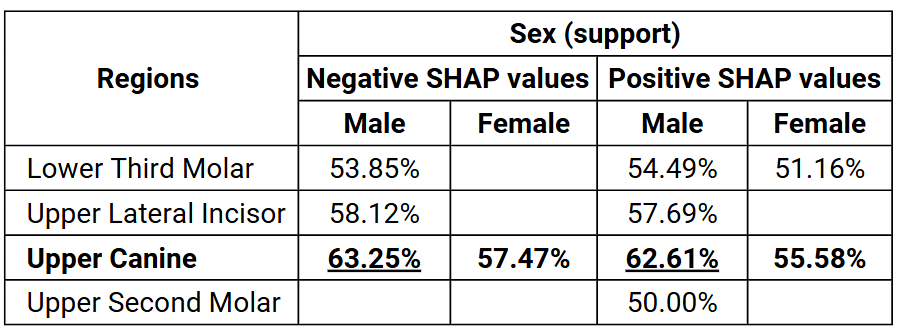


In [ ]:
upper_canine = pos_final[pos_final['name']== 'Upper Canine']
print(upper_canine.shape)
upper_canine.head()

In [ ]:
canine_male = upper_canine[upper_canine['Gender_predict_str']=='Male']
print(canine_male.shape)
canine_male.head()

In [ ]:
canine_male_correct = canine_male[((canine_male['Gender_predict_str'] == 'Male') & (canine_male['Gender'] == 'M'))& (canine_male['Prob'] >= 0.95)]
canine_male_correct.shape


In [ ]:
canine_male_incorrect = canine_male[((canine_male['Gender_predict_str'] == 'Male') & (canine_male['Gender'] == 'F')) & (canine_male['Prob'] >= 0.5) & (canine_male['Prob'] <= 0.55)]
print(canine_male_incorrect.shape)
canine_male_incorrect.head()

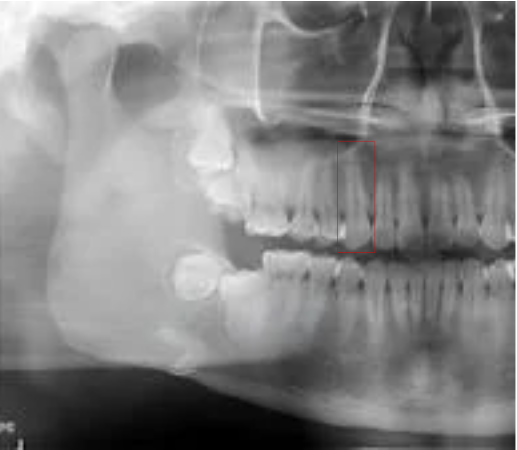


## Affine

### scale x

In [ ]:
from PIL import Image

def enlarge_tooth_region(image, x_center, y_center, width, height, scale_x=1.0, scale_y=1.0):
    """
    ขยายความกว้างและสูงของบริเวณฟันกรามซี่ที่ 3 บนในภาพถ่ายรังสีพาโนรามา

    Parameters:
    image (PIL Image): ภาพถ่ายรังสีพาโนรามา
    x_center, y_center (float): พิกัดศูนย์กลางของบริเวณที่ต้องการขยาย (0-1)
    width, height (float): ความกว้างและความสูงของบริเวณที่ต้องการขยาย (0-1)
    scale_x, scale_y (float): ค่าการขยายความกว้างและความสูง

    Returns:
    result_image (PIL Image): ภาพที่ถูกปรับขนาดเรียบร้อยแล้ว
    """
    # ขนาดภาพ
    img_width, img_height = image.size

    # คำนวณพิกัดจริง   --> ความจริงควรหา code ที่คำนวณพิกัดจริง ๆ มาเลย
    w = int(width * img_width)
    h = int(height * img_height)
    x = int((x_center * img_width) - (w / 2))
    y = int((y_center * img_height) - (h / 2))

    # ตรวจสอบว่าพิกัดอยู่ภายในขอบเขตของภาพ
    x = max(0, x)
    y = max(0, y)
    x2 = min(img_width, x + w)
    y2 = min(img_height, y + h)

    # แยกบริเวณที่ต้องการขยาย
    roi = image.crop((x, y, x2, y2))

    # คำนวณขนาดใหม่หลังจากการขยาย
    new_width = int(w * scale_x)
    new_height = int(h * scale_y)

    # ขยายขนาดบริเวณที่ต้องการ
    resized_roi = roi.resize((new_width, new_height), Image.LANCZOS)

    # คำนวณพิกัดใหม่หลังจากการขยาย
    new_x = x - (new_width - w) // 2
    new_y = y - (new_height - h) // 2

    # ตรวจสอบว่าพิกัดใหม่อยู่ภายในขอบเขตของภาพ
    new_x_ = max(0, new_x)
    new_y_ = max(0, new_y)
    new_width_ = min(img_width, new_x + new_width) #width
    new_height_ = min(img_height, new_y + new_height)

    # สร้างสำเนาของภาพเดิมเพื่อไม่ให้แก้ไขภาพต้นฉบับ
    result_image = image.copy()

    # รวมบริเวณที่ขยายกลับเข้ากับภาพเดิม
    result_image.paste(resized_roi, (new_x, new_y))

    return result_image,new_x,new_y,new_width,new_height

In [ ]:
def generate_numbers(start_neg, stop_neg, start_pos, stop_pos, step):
    negative_numbers = [round(x, 2) for x in np.arange(start_neg, stop_neg, -step)]
    positive_numbers = [1.0] + [round(x, 2) for x in np.arange(start_pos, stop_pos, -step)]
    return negative_numbers + positive_numbers

In [ ]:
numbers = generate_numbers(start_neg=0.95, stop_neg=0.74, start_pos=1.25, stop_pos=1.04, step=0.01)

# Print the generated numbers
print(numbers)
print(len(numbers))

In [ ]:
# ตัวอย่างการเรียกใช้ฟังก์ชัน
scale_x = numbers

dataframe = []
# list_df = [] #keep


for i in range(len(df)):
    image_array = cv2.imread(df['img_path'][i]) # data type = array
    image = Image.fromarray(image_array.astype('uint8')) # change array  to PIL.Image.Image type

    # ข้อมูลพิกัดจาก Custom Vision (สมมติ)
    width = df['Rwidth'][i]
    height = df['Rheight'][i]
    x_center = df['x_center'][i]
    y_center = df['y_center'][i]

    for number in scale_x:
        result_image = enlarge_tooth_region(image, x_center, y_center, width, height, scale_x= number)
        path_name = df['img_path'][i]
        filename = df['img_path'][i].split("/")[-1]
        gender = df['img_path'][i].split("/")[-2]
        age =  df['img_path'][i].split("/")[-3].split("Y")[0]
        number = number
        image_path = f"/media/tohn/HDD/Natdata/Tooth_data/Gender_ISBI2025/Affine/correct/scale_x/positive/adjust_x_{number}_{filename}"
        # print(image_path)
        # Save image
        result_image[0].save(image_path)

        # Prepare DataFrame for storing results
        df_aff = pd.DataFrame({
            'filename': [filename],
            'age(year)': [age],
            'gender': [gender],
            'path_name_ori': [df['img_path'][i]],
            'x_ori': [df['left'][i]],
            'y_ori': [df['top'][i]],
            'width_ori': [df['width'][i]],
            'height_ori': [df['height'][i]],
            'scale_x':[number],
            'scale_y':[1.00],
            'filename_adj': [image_path.split("/")[-1]],
            'path_name_adj': [image_path],
            'x_adj': [result_image[1]],
            'y_adj': [result_image[2]],
            'width_adj': [result_image[3]],
            'height_adj': [result_image[4]]
        })

        dataframe.append(df_aff)  # Append to the list

# Combine all individual DataFrames into one
result_x = pd.concat(dataframe, ignore_index=True)

result_x

### scale y

In [ ]:
from PIL import Image

def enlarge_tooth_region(image, x_center, y_center, width, height, scale_x=1.0, scale_y=1.0):
    """
    ขยายความกว้างและสูงของบริเวณฟันกรามซี่ที่ 3 บนในภาพถ่ายรังสีพาโนรามา

    Parameters:
    image (PIL Image): ภาพถ่ายรังสีพาโนรามา
    x_center, y_center (float): พิกัดศูนย์กลางของบริเวณที่ต้องการขยาย (0-1)
    width, height (float): ความกว้างและความสูงของบริเวณที่ต้องการขยาย (0-1)
    scale_x, scale_y (float): ค่าการขยายความกว้างและความสูง

    Returns:
    result_image (PIL Image): ภาพที่ถูกปรับขนาดเรียบร้อยแล้ว
    """
    # ขนาดภาพ
    img_width, img_height = image.size

    # คำนวณพิกัดจริง   --> ความจริงควรหา code ที่คำนวณพิกัดจริง ๆ มาเลย
    w = int(width * img_width)
    h = int(height * img_height)
    x = int((x_center * img_width) - (w / 2))
    y = int((y_center * img_height) - (h / 2))

    # ตรวจสอบว่าพิกัดอยู่ภายในขอบเขตของภาพ
    x = max(0, x)
    y = max(0, y)
    x2 = min(img_width, x + w)
    y2 = min(img_height, y + h)

    # แยกบริเวณที่ต้องการขยาย
    roi = image.crop((x, y, x2, y2))

    # คำนวณขนาดใหม่หลังจากการขยาย
    new_width = int(w * scale_x)
    new_height = int(h * scale_y)

    # ขยายขนาดบริเวณที่ต้องการ
    resized_roi = roi.resize((new_width, new_height), Image.LANCZOS)

    # คำนวณพิกัดใหม่หลังจากการขยาย
    new_x = x - (new_width - w) // 2
    new_y = y - (new_height - h) // 2

    # ตรวจสอบว่าพิกัดใหม่อยู่ภายในขอบเขตของภาพ
    new_x_ = max(0, new_x)
    new_y_ = max(0, new_y)
    new_width_ = min(img_width, new_x + new_width) #width
    new_height_ = min(img_height, new_y + new_height)

    # สร้างสำเนาของภาพเดิมเพื่อไม่ให้แก้ไขภาพต้นฉบับ
    result_image = image.copy()

    # รวมบริเวณที่ขยายกลับเข้ากับภาพเดิม
    result_image.paste(resized_roi, (new_x, new_y))

    return result_image,new_x,new_y,new_width,new_height

In [ ]:
# ตัวอย่างการเรียกใช้ฟังก์ชัน
scale_y = numbers

dataframe = []
# list_df = [] #keep


for i in range(len(df)):
    image_array = cv2.imread(df['img_path'][i]) # data type = array
    image = Image.fromarray(image_array.astype('uint8')) # change array  to PIL.Image.Image type

    # ข้อมูลพิกัดจาก Custom Vision (สมมติ)
    width = df['Rwidth'][i]
    height = df['Rheight'][i]
    x_center = df['x_center'][i]
    y_center = df['y_center'][i]

    for number in scale_y:
        result_image = enlarge_tooth_region(image, x_center, y_center, width, height, scale_y= number)
        path_name = df['img_path'][i]
        filename = df['img_path'][i].split("/")[-1]
        gender = df['img_path'][i].split("/")[-2]
        age =  df['img_path'][i].split("/")[-3].split("Y")[0]
        number = number
        image_path = f"/media/tohn/HDD/Natdata/Tooth_data/Gender_ISBI2025/Affine/correct/scale_y/positive/adjust_y_{number}_{filename}"
        # print(image_path)
        # Save image
        result_image[0].save(image_path)

        # Prepare DataFrame for storing results
        df_aff = pd.DataFrame({
            'filename': [filename],
            'age(year)': [age],
            'gender': [gender],
            'path_name_ori': [df['img_path'][i]],
            'x_ori': [df['left'][i]],
            'y_ori': [df['top'][i]],
            'width_ori': [df['width'][i]],
            'height_ori': [df['height'][i]],
            'scale_x':[1.00],
            'scale_y':[number],
            'filename_adj': [image_path.split("/")[-1]],
            'path_name_adj': [image_path],
            'x_adj': [result_image[1]],
            'y_adj': [result_image[2]],
            'width_adj': [result_image[3]],
            'height_adj': [result_image[4]]
        })

        dataframe.append(df_aff)  # Append to the list

# Combine all individual DataFrames into one
result_y = pd.concat(dataframe, ignore_index=True)

result_y

## Confidence-Region Variation Plot

# X correct 95%

In [ ]:
df = pd.read_csv('/content/gdrive/MyDrive/Data_ISBI2025/Data/Pos_correct_male_UC_90percent.csv')  #data ทำใหม่
print(df.shape)
df.head(5)

(230, 27)


,Unnamed: 0,img_path,tagName,originalImage,left,top,width,height,Rleft,Rtop,...,Folder_type,Folder_name,Path_Name,Gender_Class,Gender_Predict,Age_predict,Age_predict_int,Gender_predict,Gender_predict_str,Gender_predict_int
0,0,/media/tohn/HDD/Natdata/Tooth_data/Data_Label/...,Upper Canine,https://irisprodseatraining.blob.core.windows....,445,192,34,113,0.725733,0.371091,...,Normal,Both,/media/data/Natdata/Tooth_data/Data_Cut_images...,1,Male,21.508780,22.0,0.999804,Male,1.0
1,4,/media/tohn/HDD/Natdata/Tooth_data/Data_Label/...,Upper Canine,https://irisprodseatraining.blob.core.windows....,398,194,43,154,0.649186,0.334294,...,Normal,Both,/media/data/Natdata/Tooth_data/Data_Cut_images...,1,Male,24.039991,24.0,0.999999,Male,1.0
2,7,/media/tohn/HDD/Natdata/Tooth_data/Data_Label/...,Upper Canine,https://irisprodseatraining.blob.core.windows....,416,216,37,102,0.678502,0.417423,...,Normal,Both,/media/data/Natdata/Tooth_data/Data_Cut_images...,1,Male,22.911680,23.0,0.999999,Male,1.0
3,8,/media/tohn/HDD/Natdata/Tooth_data/Data_Label/...,Upper Canine,https://irisprodseatraining.blob.core.windows....,429,181,34,113,0.699674,0.349855,...,Normal,Both,/media/data/Natdata/Tooth_data/Data_Cut_images...,1,Male,20.920568,21.0,1.000000,Male,1.0
4,12,/media/tohn/HDD/Natdata/Tooth_data/Data_Label/...,Upper Canine,https://irisprodseatraining.blob.core.windows....,417,199,33,102,0.680130,0.385763,...,Normal,Rt,/media/data/Natdata/Tooth_data/Data_Cut_images...,1,Male,18.262451,18.0,0.999999,Male,1.0


In [ ]:
df['prob'] = df['Gender_predict']

## data translation

In [ ]:
predict_data = pd.read_csv('/content/gdrive/MyDrive/Data_ISBI2025/Data/predict_pos_cor_scale_x.csv')  #data ทำใหม่
predict_data = predict_data.iloc[:,1:]
print(predict_data.shape)
predict_data.head(5)

(9890, 23)


,filename,age(year),gender,path_name_ori,x_ori,y_ori,width_ori,height_ori,scale_x,scale_y,...,y_adj,width_adj,height_adj,Age_predict,Age_predict_int,Gender_predict,Gender_predict_str,Gender_predict_int,prob,ratio_wh
0,J465.jpg,25,Male,/media/tohn/HDD/Natdata/Tooth_data/Data_Label/...,445,192,34,113,0.95,1.0,...,192,32,113,21.550528,22,0.999809,Male,1,0.999809,0.283186
1,J465.jpg,25,Male,/media/tohn/HDD/Natdata/Tooth_data/Data_Label/...,445,192,34,113,0.94,1.0,...,192,31,113,21.542452,22,0.999850,Male,1,0.999850,0.274336
2,J465.jpg,25,Male,/media/tohn/HDD/Natdata/Tooth_data/Data_Label/...,445,192,34,113,0.93,1.0,...,192,31,113,21.542452,22,0.999850,Male,1,0.999850,0.274336
3,J465.jpg,25,Male,/media/tohn/HDD/Natdata/Tooth_data/Data_Label/...,445,192,34,113,0.92,1.0,...,192,31,113,21.542452,22,0.999850,Male,1,0.999850,0.274336
4,J465.jpg,25,Male,/media/tohn/HDD/Natdata/Tooth_data/Data_Label/...,445,192,34,113,0.91,1.0,...,192,30,113,21.572441,22,0.999693,Male,1,0.999693,0.265487


In [ ]:
canine = pd.read_csv('/content/gdrive/MyDrive/Data_ISBI2025/SHAP_YOLO/Positive_cor95_scaleX_positive_bboxes.csv')  #data ทำใหม่
canine = canine.iloc[:,1:]
print(canine.shape)
canine.head(5)

(73840, 9)


,ymin,xmax,ymax,confidence,class,name,filename,path_name,path_pos_img
0,81.825957,195.573518,178.833732,0.926233,0.0,Condyle,adjust_x_0.95_J465.jpg,/media/tohn/HDD/Natdata/Tooth_data/Gender_ISBI...,/media/tohn/HDD/Natdata/Tooth_data/Gender_ISBI...
1,294.094890,295.225731,363.354429,0.914526,11.0,Lower Third Molar,adjust_x_0.95_J465.jpg,/media/tohn/HDD/Natdata/Tooth_data/Gender_ISBI...,/media/tohn/HDD/Natdata/Tooth_data/Gender_ISBI...
2,188.684760,463.150080,293.676129,0.874311,14.0,Upper First Premolar,adjust_x_0.95_J465.jpg,/media/tohn/HDD/Natdata/Tooth_data/Gender_ISBI...,/media/tohn/HDD/Natdata/Tooth_data/Gender_ISBI...
3,258.944672,204.071730,419.458600,0.854173,3.0,Mandibular angle,adjust_x_0.95_J465.jpg,/media/tohn/HDD/Natdata/Tooth_data/Gender_ISBI...,/media/tohn/HDD/Natdata/Tooth_data/Gender_ISBI...
4,289.547404,348.525072,382.079532,0.849527,13.0,Lower Second Molar,adjust_x_0.95_J465.jpg,/media/tohn/HDD/Natdata/Tooth_data/Gender_ISBI...,/media/tohn/HDD/Natdata/Tooth_data/Gender_ISBI...


In [ ]:
upper_canine = canine[canine['name']=='Upper Canine']
print(upper_canine.shape)
upper_canine.head(5)

(7524, 9)


,ymin,xmax,ymax,confidence,class,name,filename,path_name,path_pos_img
6,187.488407,479.951842,307.227350,0.831387,19.0,Upper Canine,adjust_x_0.95_J465.jpg,/media/tohn/HDD/Natdata/Tooth_data/Gender_ISBI...,/media/tohn/HDD/Natdata/Tooth_data/Gender_ISBI...
13,188.067348,480.153163,307.145376,0.841761,19.0,Upper Canine,adjust_x_0.94_J465.jpg,/media/tohn/HDD/Natdata/Tooth_data/Gender_ISBI...,/media/tohn/HDD/Natdata/Tooth_data/Gender_ISBI...
19,188.067348,480.153163,307.145376,0.841761,19.0,Upper Canine,adjust_x_0.93_J465.jpg,/media/tohn/HDD/Natdata/Tooth_data/Gender_ISBI...,/media/tohn/HDD/Natdata/Tooth_data/Gender_ISBI...
27,188.067348,480.153163,307.145376,0.841761,19.0,Upper Canine,adjust_x_0.92_J465.jpg,/media/tohn/HDD/Natdata/Tooth_data/Gender_ISBI...,/media/tohn/HDD/Natdata/Tooth_data/Gender_ISBI...
33,187.578763,479.049098,307.104343,0.823616,19.0,Upper Canine,adjust_x_0.91_J465.jpg,/media/tohn/HDD/Natdata/Tooth_data/Gender_ISBI...,/media/tohn/HDD/Natdata/Tooth_data/Gender_ISBI...


In [ ]:
prob_data = predict_data[predict_data['filename_adj'].isin(upper_canine['filename'])]
print(prob_data.shape)
prob_data.head(5)

(7524, 23)


,filename,age(year),gender,path_name_ori,x_ori,y_ori,width_ori,height_ori,scale_x,scale_y,...,y_adj,width_adj,height_adj,Age_predict,Age_predict_int,Gender_predict,Gender_predict_str,Gender_predict_int,prob,ratio_wh
0,J465.jpg,25,Male,/media/tohn/HDD/Natdata/Tooth_data/Data_Label/...,445,192,34,113,0.95,1.0,...,192,32,113,21.550528,22,0.999809,Male,1,0.999809,0.283186
1,J465.jpg,25,Male,/media/tohn/HDD/Natdata/Tooth_data/Data_Label/...,445,192,34,113,0.94,1.0,...,192,31,113,21.542452,22,0.999850,Male,1,0.999850,0.274336
2,J465.jpg,25,Male,/media/tohn/HDD/Natdata/Tooth_data/Data_Label/...,445,192,34,113,0.93,1.0,...,192,31,113,21.542452,22,0.999850,Male,1,0.999850,0.274336
3,J465.jpg,25,Male,/media/tohn/HDD/Natdata/Tooth_data/Data_Label/...,445,192,34,113,0.92,1.0,...,192,31,113,21.542452,22,0.999850,Male,1,0.999850,0.274336
4,J465.jpg,25,Male,/media/tohn/HDD/Natdata/Tooth_data/Data_Label/...,445,192,34,113,0.91,1.0,...,192,30,113,21.572441,22,0.999693,Male,1,0.999693,0.265487


## ALL

In [ ]:
df['prob'].mean()

0.9967379721304348

In [ ]:
prob_data[prob_data['scale_x']==1]['prob'].mean()

0.9971063789534884

In [ ]:
prob_data[prob_data['scale_x']==1]['ratio_wh'].mean()

0.37360764375532235

In [ ]:
max_ratio_wh = prob_data['ratio_wh'].max()
max_ratio_wh_rounded = round(max_ratio_wh, 2)
max_ratio_wh_rounded

1.03

In [ ]:
min_ratio_wh = prob_data['ratio_wh'].min()
min_ratio_wh_rounded = round(min_ratio_wh, 2)
min_ratio_wh_rounded

0.17

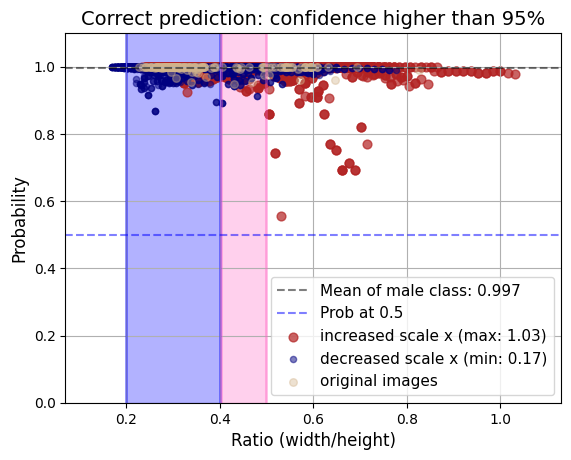

In [ ]:
#All female mean correct female
import matplotlib.pyplot as plt
import numpy as np
# plt.figure(figsize=(14, 6))

# Sample data

x_ori = prob_data[prob_data['scale_x']==1]
x1 = x_ori['ratio_wh']
y1 = pd.to_numeric(x_ori['prob'] )

x_min = prob_data[prob_data['scale_x']<1]
x2 = x_min['ratio_wh']
y2 = pd.to_numeric(x_min['prob'] )

x_max = prob_data[prob_data['scale_x']>1]
x3 = x_max['ratio_wh']
y3 = pd.to_numeric(x_max['prob'] )

# Highlight ขอบเขตสี
plt.axvspan(0.2, 0.4, color='blue', alpha=0.3)
plt.axvline(0.2, color='blue', linestyle='-', alpha=0.4, linewidth=2)
plt.axvline(0.4, color='blue', linestyle='-', alpha=0.4, linewidth=2)
plt.axvspan(0.403, 0.5, color='#ff66c4', alpha=0.3)
plt.axvline(0.403, color='#ff66c4', linestyle='-', alpha=0.4, linewidth=2)
plt.axvline(0.5, color='#ff66c4', linestyle='-', alpha=0.4, linewidth=2)


# เพิ่มเส้นประสีแดงแนวนอนที่ตำแหน่ง y
plt.axhline(y=df['prob'].mean(), color='black', linestyle='--', alpha=0.5,
            label=f"Mean of male class: {df['prob'].mean():.3f}")

plt.axhline(y=0.5, color='blue', linestyle='--', alpha=0.5, label="Prob at 0.5")


# Creating the scatter plot
plt.scatter(x3, y3, alpha=0.7, color='firebrick',s=40, label=f'increased scale x (max: {max_ratio_wh_rounded})')
plt.scatter(x2, y2, alpha=0.5, color='navy', s=20, label=f'decreased scale x (min: {min_ratio_wh_rounded})')
plt.scatter(x1, y1, alpha=0.4, color='tan', s=30,label='original images')

# # Setting custom tick marks for Y-axis
plt.yticks(ticks=[0.0, 0.2, 0.4, 0.6, 0.8, 1.0])
plt.ylim(0.,1.1)
plt.xlim(min_ratio_wh_rounded-0.1, max_ratio_wh_rounded+0.1)

plt.grid(True)

# Adding labels and title
plt.xlabel('Ratio (width/height)', fontsize=12)
plt.ylabel('Probability', fontsize=12)
plt.title('Correct prediction: confidence higher than 95%', fontsize=14)
plt.legend(loc='lower right', fontsize=11)

# Displaying the plot
plt.show()

## Mean

In [ ]:
print('Male')
print(f'row:{len(prob_data)}')
print(f"files:{len(set(prob_data['filename']))}")
prob_data.groupby('ratio_wh')['prob'].mean()

Male
row:7524
files:228


,prob
ratio_wh,
0.168919,0.999992
0.170886,0.999325
0.173611,0.998068
0.175182,0.999990
0.175573,0.999998
...,...
0.968254,0.982708
0.984127,0.986039
1.000000,0.985904


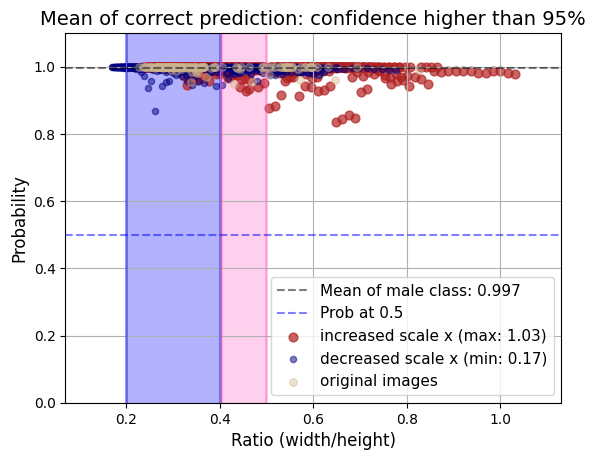

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

x_ori = prob_data[prob_data['scale_x']==1]
x_ori = x_ori.groupby('ratio_wh')['prob'].mean()
x1 = x_ori.index.tolist()
y1 = x_ori.tolist()

x_min = prob_data[prob_data['scale_x']<1]
x_min = x_min.groupby('ratio_wh')['prob'].mean()
x2 = x_min.index.tolist()
y2 = x_min.tolist()

x_max = prob_data[prob_data['scale_x']>1]
x_max = x_max.groupby('ratio_wh')['prob'].mean()
x3 = x_max.index.tolist()
y3 = x_max.tolist()

# Highlight ขอบเขตสี
plt.axvspan(0.2, 0.4, color='blue', alpha=0.3)
plt.axvline(0.2, color='blue', linestyle='-', alpha=0.4, linewidth=2)
plt.axvline(0.4, color='blue', linestyle='-', alpha=0.4, linewidth=2)
plt.axvspan(0.403, 0.5, color='#ff66c4', alpha=0.3)
plt.axvline(0.403, color='#ff66c4', linestyle='-', alpha=0.4, linewidth=2)
plt.axvline(0.5, color='#ff66c4', linestyle='-', alpha=0.4, linewidth=2)


# เพิ่มเส้นประสีแดงแนวนอนที่ตำแหน่ง y
plt.axhline(y=df['prob'].mean(), color='black', linestyle='--', alpha=0.5,
            label=f"Mean of male class: {df['prob'].mean():.3f}")

plt.axhline(y=0.5, color='blue', linestyle='--', alpha=0.5, label="Prob at 0.5")

# Creating the scatter plot
plt.scatter(x3, y3, alpha=0.7, color='firebrick',s=40, label=f'increased scale x (max: {max_ratio_wh_rounded})')
plt.scatter(x2, y2, alpha=0.5, color='navy', s=20, label=f'decreased scale x (min: {min_ratio_wh_rounded})')
plt.scatter(x1, y1, alpha=0.4, color='tan', s=30,label='original images')


# # Setting custom tick marks for Y-axis
plt.yticks(ticks=[0.0, 0.2, 0.4, 0.6, 0.8, 1.0])
plt.ylim(0.,1.1)
plt.xlim(min_ratio_wh_rounded-0.1, max_ratio_wh_rounded+0.1)


# Adding labels and title
plt.xlabel('Ratio (width/height)', fontsize=12)
plt.ylabel('Probability', fontsize=12)
plt.title('Mean of correct prediction: confidence higher than 95%', fontsize=14)

plt.grid(True)
plt.legend(loc='lower right', fontsize=11)

# Displaying the plot
plt.show()